**Name:** \_\_HAN Zhuo\_\_

**EID:** \_\_zhuohan3\_\_

# CS5489 - Tutorial 5
## Face Detection with CNNs

In the previous tutorial, you used an MLP to detect a face in a small image patch.
In this tutorial you will train a CNN instead of an MLP.

First we need to initialize Python.  Run the below cell.

In [3]:
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
import matplotlib
from numpy import *
from sklearn import *
import os
import zipfile
import fnmatch
random.seed(100)
import skimage.io
import skimage.color
import skimage.transform
from scipy import ndimage

Next we will load torch.

In [1]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torchvision import transforms
import sys
print("Python:", sys.version, "PyTorch:", torch.__version__)

Python: 3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:16:04) [GCC 11.2.0] PyTorch: 2.9.0+cu126


## 1. Loading Data and Pre-processing
Next we need to load the images.  Download `faces.zip`, and place it in the same directory as this ipynb file.  **Do not unzip it.** Then run the following cell to load the images.

In [4]:
imgdata = {'train':[], 'test':[]}
classes = {'train':[], 'test':[]}

# the dataset is too big, so subsample the training and test sets...
# reduce training set by a factor of 4
train_subsample = 1
train_counter = [0, 0]
# maximum number of samples in each class for test set
test_maxsample = 472
test_counter = [0, 0]

# load the zip file
filename = 'faces.zip'
zfile = zipfile.ZipFile(filename, 'r')

for name in zfile.namelist():
    # check file name matches
    if fnmatch.fnmatch(name, "faces/*/*/*.png"):

        # filename is : faces/train/face/fname.png
        (fdir1, fname)  = os.path.split(name)     # get file name
        (fdir2, fclass) = os.path.split(fdir1) # get class (face, nonface)
        (fdir3, fset)   = os.path.split(fdir2) # get training/test set
        # class 1 = face; class 0 = non-face
        myclass = int(fclass == "face")

        loadme = False
        if fset == 'train':
            if (train_counter[myclass] % train_subsample) == 0:
                loadme = True
            train_counter[myclass] += 1
        elif fset == 'test':
            if test_counter[myclass] < test_maxsample:
                loadme = True
            test_counter[myclass] += 1

        if (loadme):
            # open file in memory, and parse as an image
            myfile = zfile.open(name)
            #img = matplotlib.image.imread(myfile)
            img = skimage.io.imread(myfile, as_gray=True)
            myfile.close()

            # append data
            imgdata[fset].append(img)
            classes[fset].append(myclass)


zfile.close()
imgsize = img.shape

print(len(imgdata['train']))
print(len(imgdata['test']))
trainclass2start = sum(classes['train'])

6977
944


Next we will convert the list of images into a tensor of images for easier processing.

In [5]:
# convert list to numpy array
trainY = asarray(classes['train'])
testY  = asarray(classes['test'])

# convert class labels to binary indicators
trainYb_np = zeros((len(trainY), 2))
trainYb_np[arange(len(trainY)), trainY] = 1
testYb_np = zeros((len(testY), 2))
testYb_np[arange(len(testY)), testY] = 1
trainYb = F.one_hot(torch.tensor(trainY, dtype=torch.long), num_classes=2).float()
testYb = F.one_hot(torch.tensor(testY, dtype=torch.long), num_classes=2).float()

# convert list of ndarray to ndarray (numpy version)
trainI_np = asarray(imgdata['train']).reshape((6977,19,19,1))
testI_np = asarray(imgdata['test']).reshape((944,19,19,1))
trainI = torch.tensor(trainI_np, dtype=torch.float32).permute(0, 3, 1, 2)  # Convert NHWC to NCHW
testI = torch.tensor(testI_np, dtype=torch.float32).permute(0, 3, 1, 2)   # Convert NHWC to NCHW

# cleanup memory
del imgdata

# shuffle the data (since it is in order by class)
random.seed(123)
inds1 = random.permutation(len(trainI_np)).tolist()
inds2 = random.permutation(len(testI_np)).tolist()
trainYb = trainYb[inds1]
testYb = testYb[inds2]
trainY = trainY[inds1]
testY = testY[inds2]
trainI = trainI[inds1]
testI = testI[inds2]

print(trainI.shape)
print(testI.shape)

torch.Size([6977, 1, 19, 19])
torch.Size([944, 1, 19, 19])


Each image is a 19x19x1 array of pixel values.  The last dimension is the number of channels in the image - in this case the image is grayscale, so there is only 1 channel.  Run the below code to show an example:

(19, 19)


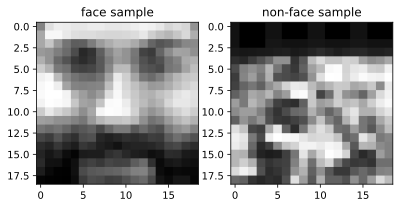

In [6]:
print(img.shape)
plt.subplot(1,2,1)
plt.imshow(squeeze(trainI[1]), cmap='gray', interpolation='nearest')
plt.title("face sample")
plt.subplot(1,2,2)
plt.imshow(squeeze(trainI[2]), cmap='gray', interpolation='nearest')
plt.title("non-face sample")
plt.show()

Run the below code to show more images!

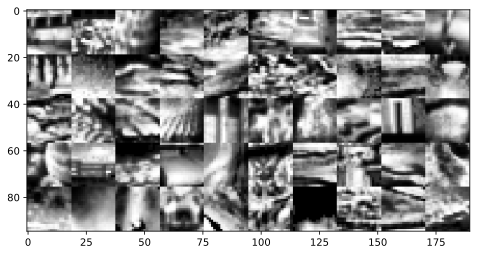

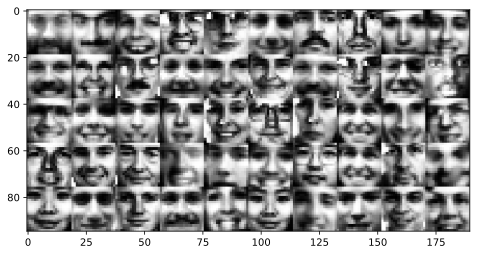

In [7]:
# function to make an image montage
def image_montage(X, imsize=None, maxw=10):
    """X can be a list of images, or a matrix of vectorized images.
      Specify imsize when X is a matrix."""
    tmp = []
    numimgs = len(X)

    # create a list of images (reshape if necessary)
    for i in range(0,numimgs):
        if imsize != None:
            tmp.append(X[i].reshape(imsize))
        else:
            tmp.append(squeeze(X[i]))

    # add blanks
    if (numimgs > maxw) and (mod(numimgs, maxw) > 0):
        leftover = maxw - mod(numimgs, maxw)
        meanimg = 0.5*(X[0].max()+X[0].min())
        for i in range(0,leftover):
            tmp.append(ones(tmp[0].shape)*meanimg)

    # make the montage
    tmp2 = []
    for i in range(0,len(tmp),maxw):
        tmp2.append( hstack(tmp[i:i+maxw]) )
    montimg = vstack(tmp2)
    return montimg

# show images in a plot
def show_imgs(W_list, nc=10, highlight_green=None, highlight_red=None, titles=None):
    # nc is the number of columns
    nfilter = len(W_list)
    nr = (nfilter - 1) // nc + 1
    for i in range(nr):
        for j in range(nc):
            idx = i * nc + j
            if idx == nfilter:
                break
            plt.subplot(nr, nc, idx + 1)
            cur_W = W_list[idx]
            plt.imshow(cur_W,cmap='gray', interpolation='nearest')
            if titles is not None:
                if isinstance(titles, str):
                    plt.title(titles.format(idx))
                else:
                    plt.title(titles[idx])

            if ((highlight_green is not None) and highlight_green[idx]) or \
               ((highlight_red is not None) and highlight_red[idx]):
                ax = plt.gca()
                if highlight_green[idx]:
                    mycol = '#00FF00'
                else:
                    mycol = 'r'
                for S in ['bottom', 'top', 'right', 'left']:
                    ax.spines[S].set_color(mycol)
                    ax.spines[S].set_lw(2.0)
                ax.xaxis.set_ticks_position('none')
                ax.yaxis.set_ticks_position('none')
                ax.set_xticks([])
                ax.set_yticks([])
            else:
                plt.gca().set_axis_off()

# show a few images
plt.figure(figsize=(9,4))
plt.imshow(image_montage(trainI[trainYb[:,0]==1][0:50]), cmap='gray', interpolation='nearest')
plt.show()

plt.figure(figsize=(9,4))
plt.imshow(image_montage(trainI[trainYb[:,1]==1][0:50]), cmap='gray', interpolation='nearest')
plt.show()

Next we will generate the training/validation set from the training data.

In [8]:
# generate fixed validation set of 10% of the training set
vtrainI, validI, vtrainYb, validYb = \
  model_selection.train_test_split(trainI, trainYb,
  train_size=0.9, test_size=0.1, random_state=4488)

# make validation data
validsetI = (validI, validYb)

print(vtrainI.shape)
print(validI.shape)

torch.Size([6279, 1, 19, 19])
torch.Size([698, 1, 19, 19])


Here are some useful functions.

In [9]:
def plot_history(history):
    fig, ax1 = plt.subplots()

    ax1.plot(history.history['loss'], 'r', label="training loss ({:.6f})".format(history.history['loss'][-1]))
    ax1.plot(history.history['val_loss'], 'r--', label="validation loss ({:.6f})".format(history.history['val_loss'][-1]))
    ax1.grid(True)
    ax1.set_xlabel('iteration')
    ax1.legend(loc="best", fontsize=9)
    ax1.set_ylabel('loss', color='r')
    ax1.tick_params('y', colors='r')

    if 'accuracy' in history.history:
        ax2 = ax1.twinx()

        ax2.plot(history.history['accuracy'], 'b', label="training acc ({:.4f})".format(history.history['accuracy'][-1]))
        ax2.plot(history.history['val_accuracy'], 'b--', label="validation acc ({:.4f})".format(history.history['val_accuracy'][-1]))

        ax2.legend(loc="best", fontsize=9)
        ax2.set_ylabel('acc', color='b')
        ax2.tick_params('y', colors='b')

EarlyStopping function or just use the lightning lib

In [10]:
# early stopping criteria
class EarlyStopping:
    def __init__(self, monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto'):
        self.monitor = monitor                         # use validation accuracy for stopping
        self.min_delta = min_delta
        self.patience = patience
        self.verbose = verbose
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                if self.verbose:
                    print(f"early stopping")
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

 Convert history to match original format

In [11]:
# Convert history to match original format
class HistoryWrapper:
    def __init__(self, history_dict):
        self.history = history_dict

Basic setting for some trainning parametes

In [127]:
batch_size = 128
epochs = 100

# Create data loaders
train_dataset = TensorDataset(vtrainI, vtrainYb)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_dataset = TensorDataset(validI, validYb)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)


Now let's try a simple logistic regression classifier, trained using Pytorch. Since the inputs are images, we will convert the input image into a vector using the "Flatten" layer first.

early stopping
test accuracy: 0.6016949152542372


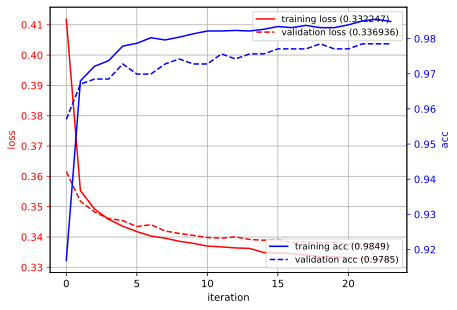

In [13]:
# initialize random seed
torch.manual_seed(4487)
random.seed(4487)

# build the network for logistic regression
nn_model = nn.Sequential(
    nn.Flatten(),                                     # vectorize the input image
    nn.Linear(19*19*1, 2),                           # classification layer (2 classes)
    nn.Softmax(dim=1)
)

# early stopping criteria
earlystop = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list = [earlystop]

# compile and fit the network
criterion = nn.CrossEntropyLoss()                     # categorical_crossentropy equivalent
optimizer = optim.SGD(nn_model.parameters(), lr=0.05, momentum=0.9, nesterov=True)
                                                      # also calculate accuracy during training

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(epochs):
    # Training phase
    nn_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = nn_model(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    # Validation phase
    nn_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            outputs = nn_model(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    # Calculate metrics
    train_loss /= len(train_loader)
    val_loss /= len(valid_loader)
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    # Store history
    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)

    # Early stopping check
    earlystop(val_acc)
    if earlystop.early_stop:
        break


history = HistoryWrapper(history)

plot_history(history)

# Prediction
nn_model.eval()
with torch.no_grad():
    pred_outputs = nn_model(testI)                    # verbose=False equivalent
    predY = torch.argmax(pred_outputs, dim=1).numpy()

acc = metrics.accuracy_score(testY, predY)
print("test accuracy:", acc)


## 2. Detection using CNN

Train an CNN to classify an image patch as face or not face.  Use  `vtrainI` and `vtrainY` as the training set and `validsetI` as the validation set.  You can try different architectures, and adjust values of the learning rates, number of iterations, early stopping, regularization, etc. to get a good result.  Use a large batch size (e.g., 50) to speed up the training time.  Remember to add the `callbacks` so that you can monitor the training process.

In [14]:
### INSERT YOUR CODE HERE
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, k=3, use_bn=True, dropout=0.0):
        super().__init__()
        padding = k // 2
        layers = [nn.Conv2d(in_c, out_c, k, padding=padding, bias=not use_bn)]
        if use_bn:
            layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.ReLU(inplace=True))
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class FaceCNN19(nn.Module):
    def __init__(
        self,
        in_ch: int = 1,
        num_classes: int = 2,
        width: int = 32,
        depths=(1, 1, 1),
        k: int = 3,
        pool: str = "max",
        dropout: float = 0.25,
        use_bn: bool = True,
    ):
        super().__init__()
        chans = [width, width * 2, width * 4][: len(depths)]
        stages = []
        in_c = in_ch
        for out_c, d in zip(chans, depths):
            
            blocks = [ConvBlock(in_c if i == 0 else out_c, out_c, k=k,
                                use_bn=use_bn, dropout=dropout) for i in range(d)]
            stage = nn.Sequential(*blocks)
            stages.append(stage)
            
            if pool == "max":
                stages.append(nn.MaxPool2d(2))
            elif pool == "avg":
                stages.append(nn.AvgPool2d(2))
            in_c = out_c
        self.stem = nn.Sequential(*stages)
        self.gap = nn.AdaptiveAvgPool2d(1)      
        self.head = nn.Linear(chans[-1], num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1.0); nn.init.constant_(m.bias, 0.0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.zeros_(m.bias)

    def forward(self, x):                  
        x = self.stem(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        return self.head(x)


In [128]:
model_simple_cnn  = FaceCNN19(width=64, depths=(4,4,4),   k=3, dropout=0.30)

Epoch [1/100], Train Loss: 0.0129, Train Accuracy: 0.9954, Val Loss: 0.0339, Val Accuracy: 0.9885
Epoch [2/100], Train Loss: 0.0147, Train Accuracy: 0.9957, Val Loss: 0.0180, Val Accuracy: 0.9943
Epoch [3/100], Train Loss: 0.0146, Train Accuracy: 0.9952, Val Loss: 0.0209, Val Accuracy: 0.9928
Epoch [4/100], Train Loss: 0.0246, Train Accuracy: 0.9959, Val Loss: 0.0722, Val Accuracy: 0.9914
Epoch [5/100], Train Loss: 0.0777, Train Accuracy: 0.9750, Val Loss: 0.0470, Val Accuracy: 0.9842
Epoch [6/100], Train Loss: 0.0478, Train Accuracy: 0.9828, Val Loss: 0.0547, Val Accuracy: 0.9857
Epoch [7/100], Train Loss: 0.0296, Train Accuracy: 0.9904, Val Loss: 0.0310, Val Accuracy: 0.9871
early stopping
test accuracy: 0.8792372881355932


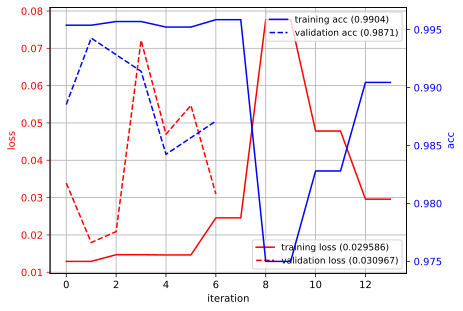

In [131]:
earlystop_simple_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_simple_cnn = [earlystop_simple_cnn]

criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(model_simple_cnn.parameters(), lr=0.05, momentum=0.9, nesterov=True)

history_simple_cnn = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

model_simple_cnn = model_simple_cnn.to(device)
criterion = nn.CrossEntropyLoss().to(device)

optimizer = optim.SGD(model_simple_cnn.parameters(), lr=3e-2, momentum=0.9, nesterov=True)

for epoch in range(epochs):
    model_simple_cnn.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()
        outputs = model_simple_cnn(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_simple_cnn['loss'].append(train_loss)
    history_simple_cnn['accuracy'].append(train_accuracy)

    # Validation phase
    model_simple_cnn.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_simple_cnn(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_simple_cnn[
        'loss'].append(train_loss)
    history_simple_cnn['accuracy'].append(train_accuracy)
    history_simple_cnn['val_loss'].append(val_loss)
    history_simple_cnn['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

    # Check for early stopping
    earlystop_simple_cnn(val_accuracy)
    if earlystop_simple_cnn.early_stop:
        break

history_simple_cnn = HistoryWrapper(history_simple_cnn)

plot_history(history_simple_cnn)
# Prediction
model_simple_cnn.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_simple_cnn = model_simple_cnn(testI)
    predY_simple_cnn = pred_outputs_simple_cnn.argmax(dim=1).detach().cpu().numpy()
acc_simple_cnn = metrics.accuracy_score(testY, predY_simple_cnn)
print("test accuracy:", acc_simple_cnn)


_How does the MLP compare to the linear and non-linear classifiers that you tried in Tutorial 4?_
- **INSERT YOUR ANSWER HERE**
- The CNN model (87.92% Acc on test set) I tried here significantly outperforms the classifiers (LR: 55.83% Acc on test set; RBF-SVM: 64.41% Acc on test set; MLP: 74.26% Acc on test set) I tried in Tutorial 4.

## 3. Data Augmentation

Now use data augmentation (introduced in the last tutorial) to try to improve the accuracy.

We can also add per-pixel noise or transformations. We define a few functions for adding per-pixel noise.  The following functions will add Gaussian pixel noise, add corruption noise (setting some input pixels to 0), scale and shift pixel values (changing contrast and brightness).

In [115]:
def add_gauss_noise(X, sigma2=0.05):
    # add Gaussian noise with zero mean, and variance sigma2
    X = X.float()
    noise = torch.normal(0, sigma2, X.shape, dtype=torch.float32, device=X.device)
    return (X + noise).float()

def add_corrupt_noise(X, p=0.1):
    # apply pixel corruption (zero out value) with probability p
    X = X.float()
    mask = torch.rand(X.shape, dtype=torch.float32, device=X.device) > p
    return (X * mask.float()).float()

def add_scale_shift(X, sigma2=0.1, alpha2=0.2):
    # randomly scale and shift the pixel values (same for each image)
    # Xnew = a X + b
    # a is sampled from a Gaussian with mean 1, and variance sigma2
    # b is sampled from a Gaussian with mean 0, and variance alpha2
    X = X.float()

    if X.ndim == 3:
        dshape = (X.shape[0], 1, 1)
    elif X.ndim == 4:
        dshape = (X.shape[0], 1, 1, 1)
    else:
        dshape = (1,)

    a = torch.normal(1, sigma2, dshape, dtype=torch.float32, device=X.device)
    b = torch.normal(0, alpha2, dshape, dtype=torch.float32, device=X.device)

    result = torch.clamp(a * X + b, 0.0, 1.0)
    return result.float()

Next, we define a function for adding per-pixel noise (in this case just Gaussian noise). The noise is included using the `transforms.Compose`.

In [116]:
# build the noise function
def addNoise(X):
    return add_gauss_noise(X, 0.04)

# build the data augmenter
transform = transforms.Compose([
    transforms.ToPILImage(),

    # Random rotation within ±10 degrees
    transforms.RandomRotation(10),

    # Random horizontal flipping
    transforms.RandomHorizontalFlip(),

    # Random affine transformation for width/height shift and shear
    transforms.RandomAffine(
        degrees=0,  # No additional rotation (already handled by RandomRotation)
        translate=(0.05, 0.05),  # Width and height shift (5% of image size)
        shear=5  # Shearing within ±5 degrees
    ),

    # Random zooming (simulated using RandomResizedCrop)
    transforms.RandomResizedCrop(size=(19, 19), scale=(0.95, 1.05)),  # Adjust size if needed

    # Convert PIL image to PyTorch tensor
    transforms.ToTensor(),

    # Add custom noise
    transforms.Lambda(addNoise)
])

Next we can show some examples of augmented images. Run the code below to see different random augmentations.

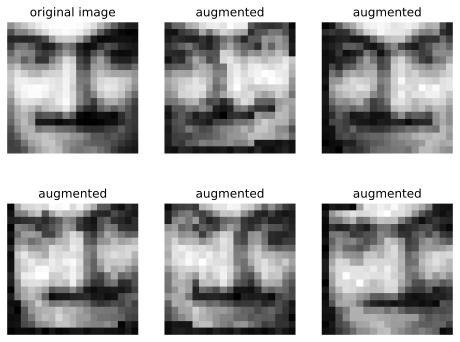

In [117]:
img = trainI[4]
imgs = [img[0].detach().numpy()]

cnt = 0
while cnt < 5:
    # Apply augmentation - img already has correct shape (1, 19, 19)
    augmented = transform(img)

    # Convert to numpy for display (remove channel dimension)
    augmented_np = augmented[0].detach().numpy()

    imgs.append(augmented_np)
    cnt += 1

titles = ['original image', 'augmented', 'augmented', 'augmented', 'augmented', 'augmented']
plt.figure(figsize=(8,6))
show_imgs(imgs, nc=3, titles=titles)


The augmented images look similar to the original image, but contain small differences that the network can use to learn more about the class.

Now let's try training logistic regression with data augmentation.  We also disable early stopping so that the training sees more augmented data.

Customize dataset for augmentation and set some parameters

In [323]:
class AugmentedTensorDataset(TensorDataset):
    def __init__(self, *tensors, transform=None):
        super().__init__(*tensors)
        self.transform = transform

    def __getitem__(self, index):
        img = self.tensors[0][index]
        label = self.tensors[1][index]

        if self.transform:
            img = self.transform(img)

        return img, label

batch_size = 1024
epochs = 50
steps_per_epoch = len(vtrainI)/batch_size

# Create data loaders
train_dataset = AugmentedTensorDataset(trainI, trainYb, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_dataset = TensorDataset(validI, validYb)       # specify the validation set
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)


In [168]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [188]:
earlystop = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list = [earlystop]
torch.manual_seed(4487)
random.seed(4487)

# build the network for logistic regression
nn_model = nn.Sequential(
    nn.Flatten(),                                     # vectorize the input image
    nn.Linear(19*19*1, 2),                           # classification layer (2 classes)
    nn.Softmax(dim=1)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

nn_model = nn_model.to(device)
if torch.cuda.device_count() >= 2:
    print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
    nn_model = nn.DataParallel(nn_model, device_ids=[0, 1])  # 关键一行

# nn_model = nn_model.to(device)

# compile and fit the network
criterion = nn.CrossEntropyLoss()                     # categorical_crossentropy equivalent
optimizer = optim.SGD(nn_model.parameters(), lr=0.05, momentum=0.9, nesterov=True)
                                                      # also calculate accuracy during training

criterion = criterion.to(device)
# optimizer = optimizer.to(device)

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

epochs = 50

for epoch in range(epochs):
    # Training phase
    nn_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
      batch_x = batch_x.to(device)
      batch_y = batch_y.to(device)
      # print(batch_x)
      optimizer.zero_grad()
      outputs = nn_model(batch_x)
      loss = criterion(outputs, torch.argmax(batch_y, dim=1))
      loss.backward()
      optimizer.step()

      train_loss += loss.item()
      _, predicted = torch.max(outputs.data, 1)
      train_total += batch_y.size(0)
      train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

      # step_count += 1
      # if step_count >= steps_per_epoch:
      #   break

    # Validation phase
    nn_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
      for batch_x, batch_y in valid_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        outputs = nn_model(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))

        val_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        val_total += batch_y.size(0)
        val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    # Calculate metrics
    avg_train_loss = train_loss/len(train_loader)
    avg_val_loss = val_loss / len(valid_loader)
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    # Store history
    history['loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)


    print(f'Epoch {epoch+1}/{epochs} - '
      f'loss: {avg_train_loss:.4f} - '
      f'accuracy: {train_acc:.4f} - '
      f'val_loss: {avg_val_loss:.4f} - '
      f'val_accuracy: {val_acc:.4f}')
    
    earlystop(val_acc)
    if earlystop.early_stop:
        break


history = HistoryWrapper(history)



Using 2 GPUs via DataParallel: [0,1]
Epoch 1/50 - loss: 0.6370 - accuracy: 0.6256 - val_loss: 0.5476 - val_accuracy: 0.8223
Epoch 2/50 - loss: 0.5316 - accuracy: 0.8379 - val_loss: 0.4507 - val_accuracy: 0.9255
Epoch 3/50 - loss: 0.4719 - accuracy: 0.8772 - val_loss: 0.4178 - val_accuracy: 0.9269
Epoch 4/50 - loss: 0.4498 - accuracy: 0.8851 - val_loss: 0.4040 - val_accuracy: 0.9312
Epoch 5/50 - loss: 0.4382 - accuracy: 0.8888 - val_loss: 0.3982 - val_accuracy: 0.9312
Epoch 6/50 - loss: 0.4330 - accuracy: 0.8935 - val_loss: 0.3904 - val_accuracy: 0.9341
Epoch 7/50 - loss: 0.4285 - accuracy: 0.8955 - val_loss: 0.3879 - val_accuracy: 0.9355
Epoch 8/50 - loss: 0.4243 - accuracy: 0.8998 - val_loss: 0.3857 - val_accuracy: 0.9370
Epoch 9/50 - loss: 0.4246 - accuracy: 0.8982 - val_loss: 0.3848 - val_accuracy: 0.9370
Epoch 10/50 - loss: 0.4208 - accuracy: 0.9002 - val_loss: 0.3827 - val_accuracy: 0.9398
Epoch 11/50 - loss: 0.4186 - accuracy: 0.9067 - val_loss: 0.3815 - val_accuracy: 0.9413
Epoc

test accuracy: 0.7574152542372882


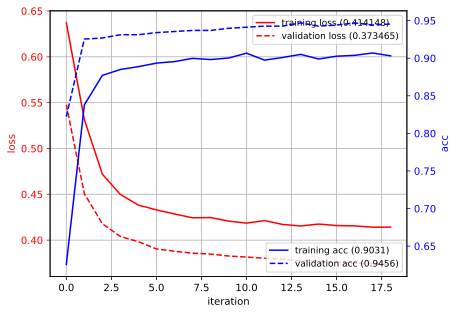

In [189]:
plot_history(history)

# Prediction
nn_model.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs = nn_model(testI)                    # verbose=False equivalent
    predY = torch.argmax(pred_outputs, dim=1).detach().cpu().numpy()

acc = metrics.accuracy_score(testY, predY)
print("test accuracy:", acc)

Using data augmentation, the test accuracy improves from 0.60 to 0.70! (your numbers may be different)

Now train your best CNN from the previous section using data augmentation.
Try different per-pixel noise levels, and different options of the transforms,
and combinations of them.  Hopefully you should be able to improve the accuracy!

In [321]:
### INSERT YOUR CODE HERE ###
model_aug_cnn = FaceCNN19(width=64, depths=(4,4,4), k=3, dropout=0.30)

cuda
Epoch [1/50], Train Loss: 0.0802, Train Accuracy: 0.9696, Val Loss: 0.3025, Val Accuracy: 0.9241
Epoch [2/50], Train Loss: 0.0540, Train Accuracy: 0.9815, Val Loss: 0.2094, Val Accuracy: 0.9484
Epoch [3/50], Train Loss: 0.0469, Train Accuracy: 0.9844, Val Loss: 0.0728, Val Accuracy: 0.9785
Epoch [4/50], Train Loss: 0.0392, Train Accuracy: 0.9880, Val Loss: 0.0469, Val Accuracy: 0.9814
Epoch [5/50], Train Loss: 0.0352, Train Accuracy: 0.9877, Val Loss: 0.0477, Val Accuracy: 0.9871
Epoch [6/50], Train Loss: 0.0336, Train Accuracy: 0.9890, Val Loss: 0.0286, Val Accuracy: 0.9928
Epoch [7/50], Train Loss: 0.0253, Train Accuracy: 0.9911, Val Loss: 0.0436, Val Accuracy: 0.9900
Epoch [8/50], Train Loss: 0.0239, Train Accuracy: 0.9920, Val Loss: 0.0151, Val Accuracy: 0.9971
Epoch [9/50], Train Loss: 0.0255, Train Accuracy: 0.9918, Val Loss: 0.0228, Val Accuracy: 0.9943
Epoch [10/50], Train Loss: 0.0267, Train Accuracy: 0.9908, Val Loss: 0.0266, Val Accuracy: 0.9928
Epoch [11/50], Train Los

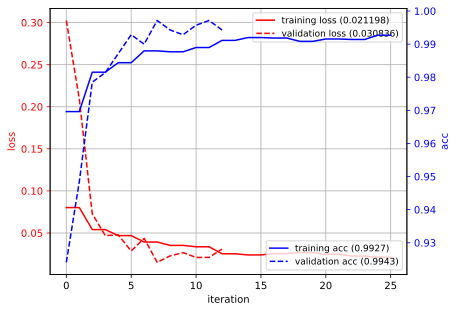

In [324]:
# criterion = nn.CrossEntropyLoss()
earlystop_aug_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_aug_cnn = [earlystop_aug_cnn]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

print(device)

model_aug_cnn = model_aug_cnn.to(device)
# if torch.cuda.device_count() >= 2:
#     print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
#     model_aug_cnn = nn.DataParallel(model_aug_cnn, device_ids=[0, 1])  # 关键一行
history_aug_cnn = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
criterion = nn.CrossEntropyLoss().to(device)
# primary = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = optim.SGD(model_aug_cnn.parameters(), lr=3e-4, momentum=0.9, nesterov=True)
optimizer = torch.optim.AdamW(model_aug_cnn.parameters(), lr=3e-3, weight_decay=1e-2)

for epoch in range(epochs):
    model_aug_cnn.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # model_aug_cnn = model_aug_cnn.to(device)
        optimizer.zero_grad()
        # print(f"optimizer device: {optimizer.param_groups[0]['params']}")
        # print(F"batch_x device: {batch_x.device}")
        # print(F"batch_y device: {batch_y.device}")
        # print(f"model device: {model_aug_cnn.parameters()}")
        outputs = model_aug_cnn(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_aug_cnn['loss'].append(train_loss)
    history_aug_cnn['accuracy'].append(train_accuracy)

    # Validation phase
    model_aug_cnn.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_aug_cnn(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_aug_cnn[
        'loss'].append(train_loss)
    history_aug_cnn['accuracy'].append(train_accuracy)
    history_aug_cnn['val_loss'].append(val_loss)
    history_aug_cnn['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Check for early stopping
    earlystop_aug_cnn(val_accuracy)
    if earlystop_aug_cnn.early_stop:
        break

plot_history(HistoryWrapper(history_aug_cnn))
model_aug_cnn.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_aug_cnn = model_aug_cnn(testI)
    predY_aug_cnn = pred_outputs_aug_cnn.argmax(dim=1).detach().cpu().numpy()
acc_aug_cnn = metrics.accuracy_score(testY, predY_aug_cnn)
print("test accuracy:", acc_aug_cnn)

In [201]:
import random
from functools import partial

def with_prob(p, f):
    def g(x):
        return f(x) if random.random() < p else x
    return g

def compose(*fns):
    def tf(x):
        for f in fns:
            if f is not None:
                x = f(x)
        return x
    return tf

G005 = partial(add_gauss_noise, sigma2=0.005)
G01  = partial(add_gauss_noise, sigma2=0.01)
G02  = partial(add_gauss_noise, sigma2=0.02)
G05  = partial(add_gauss_noise, sigma2=0.05)

C05  = partial(add_corrupt_noise, p=0.05)
C10  = partial(add_corrupt_noise, p=0.10)
C20  = partial(add_corrupt_noise, p=0.20)
C30  = partial(add_corrupt_noise, p=0.30)

S22  = partial(add_scale_shift, sigma2=0.02, alpha2=0.02)
S52  = partial(add_scale_shift, sigma2=0.05, alpha2=0.02)
S55  = partial(add_scale_shift, sigma2=0.05, alpha2=0.05)

EXPERIMENTS = {
    "G-005": compose(with_prob(1.0, G005)),
    "G-010": compose(with_prob(1.0, G01)),
    "G-020": compose(with_prob(1.0, G02)),
    "G-050": compose(with_prob(1.0, G05)),

    "C-005": compose(with_prob(1.0, C05)),
    "C-010": compose(with_prob(1.0, C10)),
    "C-020": compose(with_prob(1.0, C20)),
    "C-030": compose(with_prob(1.0, C30)),

    "S-22":  compose(with_prob(1.0, S22)),
    "S-52":  compose(with_prob(1.0, S52)),
    "S-55":  compose(with_prob(1.0, S55)),

    "G01+C10": compose(with_prob(1.0, G01), with_prob(1.0, C10)),
    "G02+S52": compose(with_prob(1.0, G02), with_prob(1.0, S52)),
    "C10+S52": compose(with_prob(1.0, C10), with_prob(1.0, S52)),

    "Weak":   compose(with_prob(0.5, G01), with_prob(0.5, C05), with_prob(0.5, S22)),
    "Strong": compose(with_prob(0.7, G02), with_prob(0.7, C10), with_prob(0.7, S52)),
}


cuda
Epoch [1/50], Train Loss: 0.6439, Train Accuracy: 0.6627, Val Loss: 1.0295, Val Accuracy: 0.6519
Epoch [2/50], Train Loss: 0.3846, Train Accuracy: 0.8419, Val Loss: 0.6735, Val Accuracy: 0.8696
Epoch [3/50], Train Loss: 0.2048, Train Accuracy: 0.9156, Val Loss: 0.6099, Val Accuracy: 0.8309
Epoch [4/50], Train Loss: 0.1212, Train Accuracy: 0.9560, Val Loss: 1.4212, Val Accuracy: 0.6676
Epoch [5/50], Train Loss: 0.0853, Train Accuracy: 0.9708, Val Loss: 0.0921, Val Accuracy: 0.9742
Epoch [6/50], Train Loss: 0.0631, Train Accuracy: 0.9775, Val Loss: 0.1016, Val Accuracy: 0.9713
Epoch [7/50], Train Loss: 0.0543, Train Accuracy: 0.9814, Val Loss: 0.0545, Val Accuracy: 0.9828
Epoch [8/50], Train Loss: 0.0364, Train Accuracy: 0.9881, Val Loss: 0.0477, Val Accuracy: 0.9871
Epoch [9/50], Train Loss: 0.0295, Train Accuracy: 0.9911, Val Loss: 0.0288, Val Accuracy: 0.9928
Epoch [10/50], Train Loss: 0.0280, Train Accuracy: 0.9917, Val Loss: 0.0150, Val Accuracy: 0.9943
Epoch [11/50], Train Los

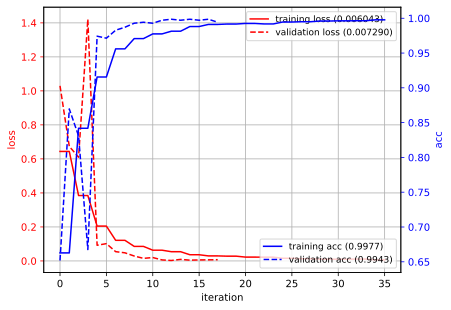

In [219]:
model_g005 = FaceCNN19(width=64, depths=(4,4,4), k=3, dropout=0.30)
name = "G-005"  
history_G005 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
train_dataset = AugmentedTensorDataset(trainI, trainYb, transform=EXPERIMENTS[name])
valid_dataset = TensorDataset(validI, validYb)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1024, shuffle=False)
# criterion = nn.CrossEntropyLoss()
earlystop_aug_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_aug_cnn = [earlystop_aug_cnn]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

print(device)

model_g005 = model_g005.to(device)
# if torch.cuda.device_count() >= 2:
#     print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
#     model_aug_cnn = nn.DataParallel(model_aug_cnn, device_ids=[0, 1])  # 关键一行

criterion = nn.CrossEntropyLoss().to(device)
# primary = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = optim.SGD(model_aug_cnn.parameters(), lr=3e-4, momentum=0.9, nesterov=True)
optimizer = torch.optim.AdamW(model_g005.parameters(), lr=3e-3, weight_decay=1e-2)

for epoch in range(epochs):
    model_g005.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # model_aug_cnn = model_aug_cnn.to(device)
        optimizer.zero_grad()
        # print(f"optimizer device: {optimizer.param_groups[0]['params']}")
        # print(F"batch_x device: {batch_x.device}")
        # print(F"batch_y device: {batch_y.device}")
        # print(f"model device: {model_aug_cnn.parameters()}")
        outputs = model_g005(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_G005['loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)

    # Validation phase
    model_g005.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_g005(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_G005[
        'loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)
    history_G005['val_loss'].append(val_loss)
    history_G005['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Check for early stopping
    earlystop_aug_cnn(val_accuracy)
    if earlystop_aug_cnn.early_stop:
        break

plot_history(HistoryWrapper(history_G005))
model_g005.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_aug_cnn = model_g005(testI)
    predY_aug_cnn = pred_outputs_aug_cnn.argmax(dim=1).detach().cpu().numpy()
acc_aug_cnn = metrics.accuracy_score(testY, predY_aug_cnn)
print("test accuracy:", acc_aug_cnn)

cuda
Epoch [1/50], Train Loss: 0.6616, Train Accuracy: 0.6107, Val Loss: 1.0456, Val Accuracy: 0.6519
Epoch [2/50], Train Loss: 0.3979, Train Accuracy: 0.8302, Val Loss: 2.8071, Val Accuracy: 0.6519
Epoch [3/50], Train Loss: 0.1970, Train Accuracy: 0.9200, Val Loss: 2.9217, Val Accuracy: 0.6533
Epoch [4/50], Train Loss: 0.1127, Train Accuracy: 0.9571, Val Loss: 1.9828, Val Accuracy: 0.6662
Epoch [5/50], Train Loss: 0.0807, Train Accuracy: 0.9679, Val Loss: 0.4792, Val Accuracy: 0.8811
Epoch [6/50], Train Loss: 0.0575, Train Accuracy: 0.9811, Val Loss: 0.1067, Val Accuracy: 0.9713
Epoch [7/50], Train Loss: 0.0400, Train Accuracy: 0.9862, Val Loss: 0.1046, Val Accuracy: 0.9656
Epoch [8/50], Train Loss: 0.0318, Train Accuracy: 0.9897, Val Loss: 0.0281, Val Accuracy: 0.9928
Epoch [9/50], Train Loss: 0.0272, Train Accuracy: 0.9921, Val Loss: 0.0158, Val Accuracy: 0.9957
Epoch [10/50], Train Loss: 0.0229, Train Accuracy: 0.9925, Val Loss: 0.0110, Val Accuracy: 0.9986
Epoch [11/50], Train Los

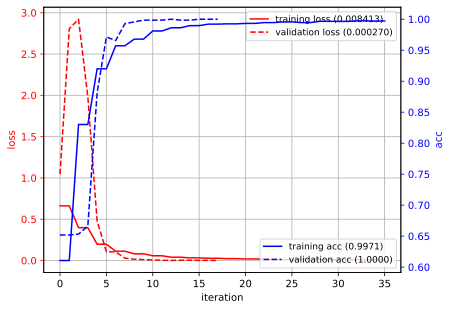

In [224]:
model_g010 = FaceCNN19(width=64, depths=(4,4,4), k=3, dropout=0.30)
name = "G-010"  
history_G005 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
train_dataset = AugmentedTensorDataset(trainI, trainYb, transform=EXPERIMENTS[name])
valid_dataset = TensorDataset(validI, validYb)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1024, shuffle=False)
# criterion = nn.CrossEntropyLoss()
earlystop_aug_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_aug_cnn = [earlystop_aug_cnn]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

print(device)

model_g010 = model_g010.to(device)
# if torch.cuda.device_count() >= 2:
#     print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
#     model_aug_cnn = nn.DataParallel(model_aug_cnn, device_ids=[0, 1])  # 关键一行

criterion = nn.CrossEntropyLoss().to(device)
# primary = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = optim.SGD(model_aug_cnn.parameters(), lr=3e-4, momentum=0.9, nesterov=True)
optimizer = torch.optim.AdamW(model_g010.parameters(), lr=3e-3, weight_decay=1e-2)

for epoch in range(epochs):
    model_g010.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # model_aug_cnn = model_aug_cnn.to(device)
        optimizer.zero_grad()
        # print(f"optimizer device: {optimizer.param_groups[0]['params']}")
        # print(F"batch_x device: {batch_x.device}")
        # print(F"batch_y device: {batch_y.device}")
        # print(f"model device: {model_aug_cnn.parameters()}")
        outputs = model_g010(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_G005['loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)

    # Validation phase
    model_g010.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_g010(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_G005[
        'loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)
    history_G005['val_loss'].append(val_loss)
    history_G005['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Check for early stopping
    earlystop_aug_cnn(val_accuracy)
    if earlystop_aug_cnn.early_stop:
        break

plot_history(HistoryWrapper(history_G005))
model_g010.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_aug_cnn = model_g010(testI)
    predY_aug_cnn = pred_outputs_aug_cnn.argmax(dim=1).detach().cpu().numpy()
acc_aug_cnn = metrics.accuracy_score(testY, predY_aug_cnn)
print("test accuracy:", acc_aug_cnn)

cuda
Epoch [1/50], Train Loss: 0.6660, Train Accuracy: 0.6099, Val Loss: 0.7490, Val Accuracy: 0.6519
Epoch [2/50], Train Loss: 0.4093, Train Accuracy: 0.8287, Val Loss: 2.4118, Val Accuracy: 0.6519
Epoch [3/50], Train Loss: 0.2246, Train Accuracy: 0.9103, Val Loss: 3.2546, Val Accuracy: 0.6519
Epoch [4/50], Train Loss: 0.1651, Train Accuracy: 0.9364, Val Loss: 2.1759, Val Accuracy: 0.6519
Epoch [5/50], Train Loss: 0.1102, Train Accuracy: 0.9593, Val Loss: 1.2663, Val Accuracy: 0.7020
Epoch [6/50], Train Loss: 0.0907, Train Accuracy: 0.9686, Val Loss: 0.2030, Val Accuracy: 0.9341
Epoch [7/50], Train Loss: 0.0715, Train Accuracy: 0.9742, Val Loss: 0.0491, Val Accuracy: 0.9857
Epoch [8/50], Train Loss: 0.0631, Train Accuracy: 0.9775, Val Loss: 0.0447, Val Accuracy: 0.9857
Epoch [9/50], Train Loss: 0.0513, Train Accuracy: 0.9815, Val Loss: 0.0236, Val Accuracy: 0.9900
Epoch [10/50], Train Loss: 0.0380, Train Accuracy: 0.9875, Val Loss: 0.0147, Val Accuracy: 0.9943
Epoch [11/50], Train Los

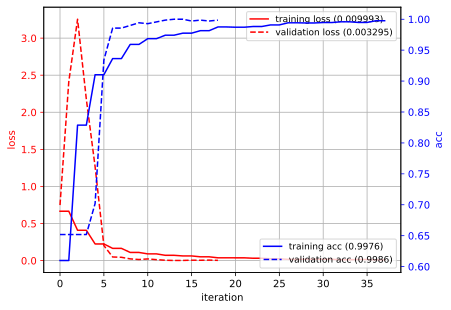

In [233]:
model_g020 = FaceCNN19(width=64, depths=(4,4,4), k=3, dropout=0.30)
name = "G-020"  
history_G005 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
train_dataset = AugmentedTensorDataset(trainI, trainYb, transform=EXPERIMENTS[name])
valid_dataset = TensorDataset(validI, validYb)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1024, shuffle=False)
# criterion = nn.CrossEntropyLoss()
earlystop_aug_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_aug_cnn = [earlystop_aug_cnn]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

print(device)

model_g020 = model_g020.to(device)
# if torch.cuda.device_count() >= 2:
#     print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
#     model_aug_cnn = nn.DataParallel(model_aug_cnn, device_ids=[0, 1])  # 关键一行

criterion = nn.CrossEntropyLoss().to(device)
# primary = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = optim.SGD(model_aug_cnn.parameters(), lr=3e-4, momentum=0.9, nesterov=True)
optimizer = torch.optim.AdamW(model_g020.parameters(), lr=3e-3, weight_decay=1e-2)

for epoch in range(epochs):
    model_g020.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # model_aug_cnn = model_aug_cnn.to(device)
        optimizer.zero_grad()
        # print(f"optimizer device: {optimizer.param_groups[0]['params']}")
        # print(F"batch_x device: {batch_x.device}")
        # print(F"batch_y device: {batch_y.device}")
        # print(f"model device: {model_aug_cnn.parameters()}")
        outputs = model_g020(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_G005['loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)

    # Validation phase
    model_g020.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_g020(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_G005[
        'loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)
    history_G005['val_loss'].append(val_loss)
    history_G005['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Check for early stopping
    earlystop_aug_cnn(val_accuracy)
    if earlystop_aug_cnn.early_stop:
        break

plot_history(HistoryWrapper(history_G005))
model_g020.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_aug_cnn = model_g020(testI)
    predY_aug_cnn = pred_outputs_aug_cnn.argmax(dim=1).detach().cpu().numpy()
acc_aug_cnn = metrics.accuracy_score(testY, predY_aug_cnn)
print("test accuracy:", acc_aug_cnn)

cuda


Epoch [1/50], Train Loss: 0.6229, Train Accuracy: 0.6536, Val Loss: 2.9648, Val Accuracy: 0.6519
Epoch [2/50], Train Loss: 0.3339, Train Accuracy: 0.8623, Val Loss: 3.4973, Val Accuracy: 0.6519
Epoch [3/50], Train Loss: 0.1992, Train Accuracy: 0.9197, Val Loss: 3.0218, Val Accuracy: 0.6519
Epoch [4/50], Train Loss: 0.1256, Train Accuracy: 0.9510, Val Loss: 1.3381, Val Accuracy: 0.6519
Epoch [5/50], Train Loss: 0.0926, Train Accuracy: 0.9666, Val Loss: 1.3705, Val Accuracy: 0.7149
Epoch [6/50], Train Loss: 0.0671, Train Accuracy: 0.9776, Val Loss: 0.1108, Val Accuracy: 0.9628
Epoch [7/50], Train Loss: 0.0524, Train Accuracy: 0.9799, Val Loss: 0.0786, Val Accuracy: 0.9785
Epoch [8/50], Train Loss: 0.0461, Train Accuracy: 0.9847, Val Loss: 0.0237, Val Accuracy: 0.9928
Epoch [9/50], Train Loss: 0.0355, Train Accuracy: 0.9877, Val Loss: 0.0237, Val Accuracy: 0.9943
Epoch [10/50], Train Loss: 0.0241, Train Accuracy: 0.9923, Val Loss: 0.0122, Val Accuracy: 0.9957
Epoch [11/50], Train Loss: 0.

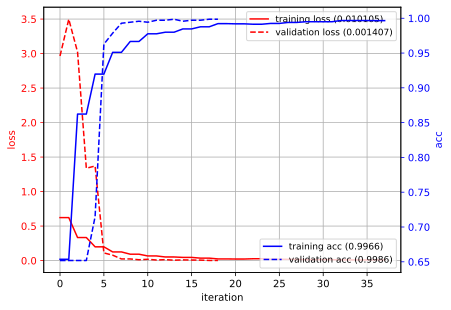

In [238]:
model_g050 = FaceCNN19(width=64, depths=(4,4,4), k=3, dropout=0.30)
name = "G-050"  
history_G005 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
train_dataset = AugmentedTensorDataset(trainI, trainYb, transform=EXPERIMENTS[name])
valid_dataset = TensorDataset(validI, validYb)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1024, shuffle=False)
# criterion = nn.CrossEntropyLoss()
earlystop_aug_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_aug_cnn = [earlystop_aug_cnn]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

print(device)

model_g050 = model_g050.to(device)
# if torch.cuda.device_count() >= 2:
#     print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
#     model_aug_cnn = nn.DataParallel(model_aug_cnn, device_ids=[0, 1])  # 关键一行

criterion = nn.CrossEntropyLoss().to(device)
# primary = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = optim.SGD(model_aug_cnn.parameters(), lr=3e-4, momentum=0.9, nesterov=True)
optimizer = torch.optim.AdamW(model_g050.parameters(), lr=3e-3, weight_decay=1e-2)

for epoch in range(epochs):
    model_g050.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # model_aug_cnn = model_aug_cnn.to(device)
        optimizer.zero_grad()
        # print(f"optimizer device: {optimizer.param_groups[0]['params']}")
        # print(F"batch_x device: {batch_x.device}")
        # print(F"batch_y device: {batch_y.device}")
        # print(f"model device: {model_aug_cnn.parameters()}")
        outputs = model_g050(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_G005['loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)

    # Validation phase
    model_g050.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_g050(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_G005[
        'loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)
    history_G005['val_loss'].append(val_loss)
    history_G005['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Check for early stopping
    earlystop_aug_cnn(val_accuracy)
    if earlystop_aug_cnn.early_stop:
        break

plot_history(HistoryWrapper(history_G005))
model_g050.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_aug_cnn = model_g050(testI)
    predY_aug_cnn = pred_outputs_aug_cnn.argmax(dim=1).detach().cpu().numpy()
acc_aug_cnn = metrics.accuracy_score(testY, predY_aug_cnn)
print("test accuracy:", acc_aug_cnn)

cuda
Epoch [1/50], Train Loss: 0.6467, Train Accuracy: 0.6347, Val Loss: 1.0875, Val Accuracy: 0.6519
Epoch [2/50], Train Loss: 0.4033, Train Accuracy: 0.8293, Val Loss: 2.1535, Val Accuracy: 0.6633
Epoch [3/50], Train Loss: 0.2587, Train Accuracy: 0.8924, Val Loss: 1.7616, Val Accuracy: 0.7436
Epoch [4/50], Train Loss: 0.1973, Train Accuracy: 0.9200, Val Loss: 1.8047, Val Accuracy: 0.6862
Epoch [5/50], Train Loss: 0.1573, Train Accuracy: 0.9387, Val Loss: 1.3034, Val Accuracy: 0.7192
Epoch [6/50], Train Loss: 0.1240, Train Accuracy: 0.9540, Val Loss: 0.1490, Val Accuracy: 0.9441
Epoch [7/50], Train Loss: 0.0986, Train Accuracy: 0.9633, Val Loss: 0.0667, Val Accuracy: 0.9756
Epoch [8/50], Train Loss: 0.0850, Train Accuracy: 0.9695, Val Loss: 0.0328, Val Accuracy: 0.9842
Epoch [9/50], Train Loss: 0.0644, Train Accuracy: 0.9751, Val Loss: 0.0283, Val Accuracy: 0.9900
Epoch [10/50], Train Loss: 0.0533, Train Accuracy: 0.9784, Val Loss: 0.0217, Val Accuracy: 0.9914
Epoch [11/50], Train Los

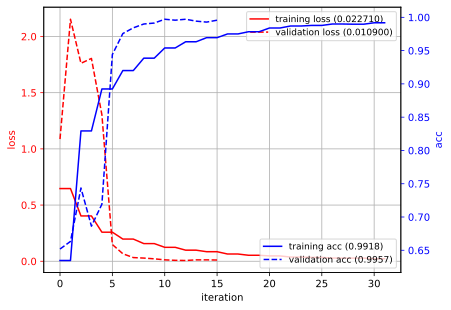

In [240]:
model_c005 = FaceCNN19(width=64, depths=(4,4,4), k=3, dropout=0.30)
name = "C-005"  
history_G005 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
train_dataset = AugmentedTensorDataset(trainI, trainYb, transform=EXPERIMENTS[name])
valid_dataset = TensorDataset(validI, validYb)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1024, shuffle=False)
# criterion = nn.CrossEntropyLoss()
earlystop_aug_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_aug_cnn = [earlystop_aug_cnn]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

print(device)

model_c005 = model_c005.to(device)
# if torch.cuda.device_count() >= 2:
#     print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
#     model_aug_cnn = nn.DataParallel(model_aug_cnn, device_ids=[0, 1])  # 关键一行

criterion = nn.CrossEntropyLoss().to(device)
# primary = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = optim.SGD(model_aug_cnn.parameters(), lr=3e-4, momentum=0.9, nesterov=True)
optimizer = torch.optim.AdamW(model_c005.parameters(), lr=3e-3, weight_decay=1e-2)

for epoch in range(epochs):
    model_c005.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # model_aug_cnn = model_aug_cnn.to(device)
        optimizer.zero_grad()
        # print(f"optimizer device: {optimizer.param_groups[0]['params']}")
        # print(F"batch_x device: {batch_x.device}")
        # print(F"batch_y device: {batch_y.device}")
        # print(f"model device: {model_aug_cnn.parameters()}")
        outputs = model_c005(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_G005['loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)

    # Validation phase
    model_c005.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_c005(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_G005[
        'loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)
    history_G005['val_loss'].append(val_loss)
    history_G005['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Check for early stopping
    earlystop_aug_cnn(val_accuracy)
    if earlystop_aug_cnn.early_stop:
        break

plot_history(HistoryWrapper(history_G005))
model_c005.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_aug_cnn = model_c005(testI)
    predY_aug_cnn = pred_outputs_aug_cnn.argmax(dim=1).detach().cpu().numpy()
acc_aug_cnn = metrics.accuracy_score(testY, predY_aug_cnn)
print("test accuracy:", acc_aug_cnn)

cuda
Epoch [1/50], Train Loss: 0.6674, Train Accuracy: 0.6384, Val Loss: 0.6584, Val Accuracy: 0.6519
Epoch [2/50], Train Loss: 0.4787, Train Accuracy: 0.7750, Val Loss: 2.6229, Val Accuracy: 0.6519
Epoch [3/50], Train Loss: 0.2768, Train Accuracy: 0.8839, Val Loss: 0.3056, Val Accuracy: 0.9026
Epoch [4/50], Train Loss: 0.2144, Train Accuracy: 0.9147, Val Loss: 0.1867, Val Accuracy: 0.9341
Epoch [5/50], Train Loss: 0.1665, Train Accuracy: 0.9364, Val Loss: 0.1801, Val Accuracy: 0.9341
Epoch [6/50], Train Loss: 0.1251, Train Accuracy: 0.9531, Val Loss: 0.0983, Val Accuracy: 0.9599
Epoch [7/50], Train Loss: 0.0983, Train Accuracy: 0.9632, Val Loss: 0.0579, Val Accuracy: 0.9842
Epoch [8/50], Train Loss: 0.0815, Train Accuracy: 0.9703, Val Loss: 0.0451, Val Accuracy: 0.9885
Epoch [9/50], Train Loss: 0.0713, Train Accuracy: 0.9759, Val Loss: 0.0356, Val Accuracy: 0.9885
Epoch [10/50], Train Loss: 0.0565, Train Accuracy: 0.9805, Val Loss: 0.0543, Val Accuracy: 0.9799
Epoch [11/50], Train Los

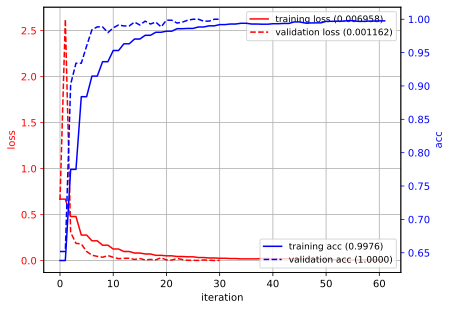

In [245]:
model_c010 = FaceCNN19(width=64, depths=(4,4,4), k=3, dropout=0.30)
name = "C-010"  
history_G005 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
train_dataset = AugmentedTensorDataset(trainI, trainYb, transform=EXPERIMENTS[name])
valid_dataset = TensorDataset(validI, validYb)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1024, shuffle=False)
# criterion = nn.CrossEntropyLoss()
earlystop_aug_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_aug_cnn = [earlystop_aug_cnn]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

print(device)

model_c010 = model_c010.to(device)
# if torch.cuda.device_count() >= 2:
#     print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
#     model_aug_cnn = nn.DataParallel(model_aug_cnn, device_ids=[0, 1])  # 关键一行

criterion = nn.CrossEntropyLoss().to(device)
# primary = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = optim.SGD(model_aug_cnn.parameters(), lr=3e-4, momentum=0.9, nesterov=True)
optimizer = torch.optim.AdamW(model_c010.parameters(), lr=3e-3, weight_decay=1e-2)

for epoch in range(epochs):
    model_c010.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # model_aug_cnn = model_aug_cnn.to(device)
        optimizer.zero_grad()
        # print(f"optimizer device: {optimizer.param_groups[0]['params']}")
        # print(F"batch_x device: {batch_x.device}")
        # print(F"batch_y device: {batch_y.device}")
        # print(f"model device: {model_aug_cnn.parameters()}")
        outputs = model_c010(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_G005['loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)

    # Validation phase
    model_c010.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_c010(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_G005[
        'loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)
    history_G005['val_loss'].append(val_loss)
    history_G005['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Check for early stopping
    earlystop_aug_cnn(val_accuracy)
    if earlystop_aug_cnn.early_stop:
        break

plot_history(HistoryWrapper(history_G005))
model_c010.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_aug_cnn = model_c010(testI)
    predY_aug_cnn = pred_outputs_aug_cnn.argmax(dim=1).detach().cpu().numpy()
acc_aug_cnn = metrics.accuracy_score(testY, predY_aug_cnn)
print("test accuracy:", acc_aug_cnn)

cuda
Epoch [1/50], Train Loss: 0.6549, Train Accuracy: 0.6261, Val Loss: 1.4837, Val Accuracy: 0.6519
Epoch [2/50], Train Loss: 0.3979, Train Accuracy: 0.8356, Val Loss: 2.9053, Val Accuracy: 0.6519
Epoch [3/50], Train Loss: 0.2579, Train Accuracy: 0.8951, Val Loss: 0.4561, Val Accuracy: 0.7865
Epoch [4/50], Train Loss: 0.2410, Train Accuracy: 0.9070, Val Loss: 0.6025, Val Accuracy: 0.6719
Epoch [5/50], Train Loss: 0.2013, Train Accuracy: 0.9219, Val Loss: 0.3919, Val Accuracy: 0.8080
Epoch [6/50], Train Loss: 0.1784, Train Accuracy: 0.9305, Val Loss: 0.2306, Val Accuracy: 0.9169
Epoch [7/50], Train Loss: 0.1432, Train Accuracy: 0.9444, Val Loss: 0.2103, Val Accuracy: 0.9097
Epoch [8/50], Train Loss: 0.1189, Train Accuracy: 0.9550, Val Loss: 0.0637, Val Accuracy: 0.9742
Epoch [9/50], Train Loss: 0.1001, Train Accuracy: 0.9630, Val Loss: 0.0681, Val Accuracy: 0.9756
Epoch [10/50], Train Loss: 0.0865, Train Accuracy: 0.9667, Val Loss: 0.0360, Val Accuracy: 0.9871
Epoch [11/50], Train Los

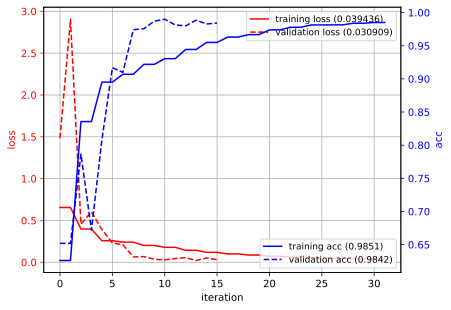

In [247]:
model_c020 = FaceCNN19(width=64, depths=(4,4,4), k=3, dropout=0.30)
name = "C-020"  
history_G005 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
train_dataset = AugmentedTensorDataset(trainI, trainYb, transform=EXPERIMENTS[name])
valid_dataset = TensorDataset(validI, validYb)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1024, shuffle=False)
# criterion = nn.CrossEntropyLoss()
earlystop_aug_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_aug_cnn = [earlystop_aug_cnn]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

print(device)

model_c020 = model_c020.to(device)
# if torch.cuda.device_count() >= 2:
#     print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
#     model_aug_cnn = nn.DataParallel(model_aug_cnn, device_ids=[0, 1])  # 关键一行

criterion = nn.CrossEntropyLoss().to(device)
# primary = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = optim.SGD(model_aug_cnn.parameters(), lr=3e-4, momentum=0.9, nesterov=True)
optimizer = torch.optim.AdamW(model_c020.parameters(), lr=3e-3, weight_decay=1e-2)

for epoch in range(epochs):
    model_c020.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # model_aug_cnn = model_aug_cnn.to(device)
        optimizer.zero_grad()
        # print(f"optimizer device: {optimizer.param_groups[0]['params']}")
        # print(F"batch_x device: {batch_x.device}")
        # print(F"batch_y device: {batch_y.device}")
        # print(f"model device: {model_aug_cnn.parameters()}")
        outputs = model_c020(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_G005['loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)

    # Validation phase
    model_c020.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_c020(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_G005[
        'loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)
    history_G005['val_loss'].append(val_loss)
    history_G005['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Check for early stopping
    earlystop_aug_cnn(val_accuracy)
    if earlystop_aug_cnn.early_stop:
        break

plot_history(HistoryWrapper(history_G005))
model_c020.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_aug_cnn = model_c020(testI)
    predY_aug_cnn = pred_outputs_aug_cnn.argmax(dim=1).detach().cpu().numpy()
acc_aug_cnn = metrics.accuracy_score(testY, predY_aug_cnn)
print("test accuracy:", acc_aug_cnn)

cuda
Epoch [1/50], Train Loss: 0.6769, Train Accuracy: 0.6305, Val Loss: 0.8419, Val Accuracy: 0.6519
Epoch [2/50], Train Loss: 0.6067, Train Accuracy: 0.6543, Val Loss: 4.3937, Val Accuracy: 0.6519
Epoch [3/50], Train Loss: 0.4506, Train Accuracy: 0.7906, Val Loss: 1.9778, Val Accuracy: 0.6519
Epoch [4/50], Train Loss: 0.2883, Train Accuracy: 0.8809, Val Loss: 1.9553, Val Accuracy: 0.6519
Epoch [5/50], Train Loss: 0.2323, Train Accuracy: 0.9051, Val Loss: 2.1439, Val Accuracy: 0.6519
Epoch [6/50], Train Loss: 0.2148, Train Accuracy: 0.9139, Val Loss: 1.0002, Val Accuracy: 0.6533
Epoch [7/50], Train Loss: 0.1803, Train Accuracy: 0.9321, Val Loss: 0.4399, Val Accuracy: 0.8338
Epoch [8/50], Train Loss: 0.1624, Train Accuracy: 0.9378, Val Loss: 0.1371, Val Accuracy: 0.9441
Epoch [9/50], Train Loss: 0.1443, Train Accuracy: 0.9452, Val Loss: 0.1042, Val Accuracy: 0.9527
Epoch [10/50], Train Loss: 0.1424, Train Accuracy: 0.9440, Val Loss: 0.1000, Val Accuracy: 0.9599
Epoch [11/50], Train Los

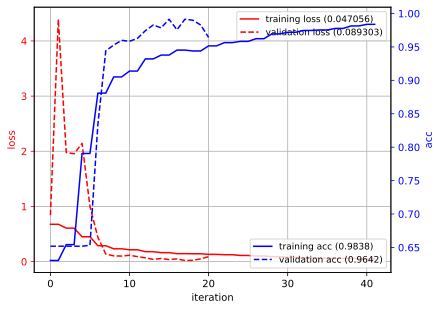

In [250]:
model_c030 = FaceCNN19(width=64, depths=(4,4,4), k=3, dropout=0.30)
name = "C-030"  
history_G005 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
train_dataset = AugmentedTensorDataset(trainI, trainYb, transform=EXPERIMENTS[name])
valid_dataset = TensorDataset(validI, validYb)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1024, shuffle=False)
# criterion = nn.CrossEntropyLoss()
earlystop_aug_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_aug_cnn = [earlystop_aug_cnn]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

print(device)

model_c030 = model_c030.to(device)
# if torch.cuda.device_count() >= 2:
#     print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
#     model_aug_cnn = nn.DataParallel(model_aug_cnn, device_ids=[0, 1])  # 关键一行

criterion = nn.CrossEntropyLoss().to(device)
# primary = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = optim.SGD(model_aug_cnn.parameters(), lr=3e-4, momentum=0.9, nesterov=True)
optimizer = torch.optim.AdamW(model_c030.parameters(), lr=3e-3, weight_decay=1e-2)

for epoch in range(epochs):
    model_c030.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # model_aug_cnn = model_aug_cnn.to(device)
        optimizer.zero_grad()
        # print(f"optimizer device: {optimizer.param_groups[0]['params']}")
        # print(F"batch_x device: {batch_x.device}")
        # print(F"batch_y device: {batch_y.device}")
        # print(f"model device: {model_aug_cnn.parameters()}")
        outputs = model_c030(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_G005['loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)

    # Validation phase
    model_c030.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_c030(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_G005[
        'loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)
    history_G005['val_loss'].append(val_loss)
    history_G005['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Check for early stopping
    earlystop_aug_cnn(val_accuracy)
    if earlystop_aug_cnn.early_stop:
        break

plot_history(HistoryWrapper(history_G005))
model_c030.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_aug_cnn = model_c030(testI)
    predY_aug_cnn = pred_outputs_aug_cnn.argmax(dim=1).detach().cpu().numpy()
acc_aug_cnn = metrics.accuracy_score(testY, predY_aug_cnn)
print("test accuracy:", acc_aug_cnn)

cuda
Epoch [1/50], Train Loss: 0.6101, Train Accuracy: 0.6830, Val Loss: 2.0333, Val Accuracy: 0.6519
Epoch [2/50], Train Loss: 0.3314, Train Accuracy: 0.8584, Val Loss: 2.4708, Val Accuracy: 0.6590
Epoch [3/50], Train Loss: 0.2005, Train Accuracy: 0.9190, Val Loss: 3.9088, Val Accuracy: 0.6519
Epoch [4/50], Train Loss: 0.1297, Train Accuracy: 0.9468, Val Loss: 1.8052, Val Accuracy: 0.6819
Epoch [5/50], Train Loss: 0.0889, Train Accuracy: 0.9669, Val Loss: 0.4284, Val Accuracy: 0.8897
Epoch [6/50], Train Loss: 0.0647, Train Accuracy: 0.9785, Val Loss: 0.1034, Val Accuracy: 0.9585
Epoch [7/50], Train Loss: 0.0558, Train Accuracy: 0.9796, Val Loss: 0.0337, Val Accuracy: 0.9900
Epoch [8/50], Train Loss: 0.0425, Train Accuracy: 0.9850, Val Loss: 0.0206, Val Accuracy: 0.9914
Epoch [9/50], Train Loss: 0.0351, Train Accuracy: 0.9887, Val Loss: 0.0176, Val Accuracy: 0.9928
Epoch [10/50], Train Loss: 0.0241, Train Accuracy: 0.9918, Val Loss: 0.0076, Val Accuracy: 0.9986
Epoch [11/50], Train Los

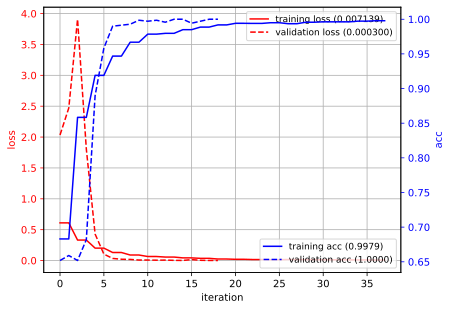

In [255]:
model_s22 = FaceCNN19(width=64, depths=(4,4,4), k=3, dropout=0.30)
name = "S-22"  
history_G005 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
train_dataset = AugmentedTensorDataset(trainI, trainYb, transform=EXPERIMENTS[name])
valid_dataset = TensorDataset(validI, validYb)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1024, shuffle=False)
# criterion = nn.CrossEntropyLoss()
earlystop_aug_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_aug_cnn = [earlystop_aug_cnn]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

print(device)

model_s22 = model_s22.to(device)
# if torch.cuda.device_count() >= 2:
#     print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
#     model_aug_cnn = nn.DataParallel(model_aug_cnn, device_ids=[0, 1])  # 关键一行

criterion = nn.CrossEntropyLoss().to(device)
# primary = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = optim.SGD(model_aug_cnn.parameters(), lr=3e-4, momentum=0.9, nesterov=True)
optimizer = torch.optim.AdamW(model_s22.parameters(), lr=3e-3, weight_decay=1e-2)

for epoch in range(epochs):
    model_s22.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # model_aug_cnn = model_aug_cnn.to(device)
        optimizer.zero_grad()
        # print(f"optimizer device: {optimizer.param_groups[0]['params']}")
        # print(F"batch_x device: {batch_x.device}")
        # print(F"batch_y device: {batch_y.device}")
        # print(f"model device: {model_aug_cnn.parameters()}")
        outputs = model_s22(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_G005['loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)

    # Validation phase
    model_s22.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_s22(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_G005[
        'loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)
    history_G005['val_loss'].append(val_loss)
    history_G005['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Check for early stopping
    earlystop_aug_cnn(val_accuracy)
    if earlystop_aug_cnn.early_stop:
        break

plot_history(HistoryWrapper(history_G005))
model_s22.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_aug_cnn = model_s22(testI)
    predY_aug_cnn = pred_outputs_aug_cnn.argmax(dim=1).detach().cpu().numpy()
acc_aug_cnn = metrics.accuracy_score(testY, predY_aug_cnn)
print("test accuracy:", acc_aug_cnn)

cuda
Epoch [1/50], Train Loss: 0.6594, Train Accuracy: 0.6183, Val Loss: 0.9817, Val Accuracy: 0.6519
Epoch [2/50], Train Loss: 0.4005, Train Accuracy: 0.8293, Val Loss: 2.1970, Val Accuracy: 0.6519
Epoch [3/50], Train Loss: 0.2153, Train Accuracy: 0.9106, Val Loss: 3.3759, Val Accuracy: 0.6519
Epoch [4/50], Train Loss: 0.1272, Train Accuracy: 0.9524, Val Loss: 0.8545, Val Accuracy: 0.6977
Epoch [5/50], Train Loss: 0.0774, Train Accuracy: 0.9729, Val Loss: 0.2689, Val Accuracy: 0.9112
Epoch [6/50], Train Loss: 0.0564, Train Accuracy: 0.9805, Val Loss: 0.1243, Val Accuracy: 0.9685
Epoch [7/50], Train Loss: 0.0443, Train Accuracy: 0.9837, Val Loss: 0.0424, Val Accuracy: 0.9914
Epoch [8/50], Train Loss: 0.0380, Train Accuracy: 0.9864, Val Loss: 0.0205, Val Accuracy: 0.9928
Epoch [9/50], Train Loss: 0.0328, Train Accuracy: 0.9903, Val Loss: 0.0214, Val Accuracy: 0.9943
Epoch [10/50], Train Loss: 0.0259, Train Accuracy: 0.9917, Val Loss: 0.0164, Val Accuracy: 0.9957
Epoch [11/50], Train Los

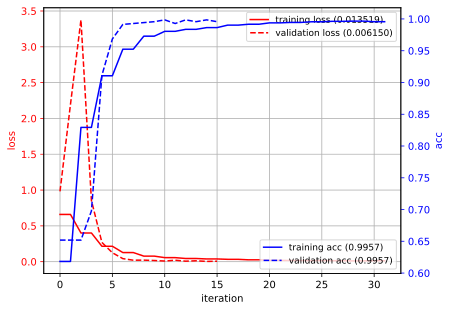

In [277]:
model_s52 = FaceCNN19(width=64, depths=(4,4,4), k=3, dropout=0.30)
name = "S-52"  
history_G005 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
train_dataset = AugmentedTensorDataset(trainI, trainYb, transform=EXPERIMENTS[name])
valid_dataset = TensorDataset(validI, validYb)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1024, shuffle=False)
# criterion = nn.CrossEntropyLoss()
earlystop_aug_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_aug_cnn = [earlystop_aug_cnn]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

print(device)

model_s52 = model_s52.to(device)
# if torch.cuda.device_count() >= 2:
#     print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
#     model_aug_cnn = nn.DataParallel(model_aug_cnn, device_ids=[0, 1])  # 关键一行

criterion = nn.CrossEntropyLoss().to(device)
# primary = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = optim.SGD(model_aug_cnn.parameters(), lr=3e-4, momentum=0.9, nesterov=True)
optimizer = torch.optim.AdamW(model_s52.parameters(), lr=3e-3, weight_decay=1e-2)

for epoch in range(epochs):
    model_s52.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # model_aug_cnn = model_aug_cnn.to(device)
        optimizer.zero_grad()
        # print(f"optimizer device: {optimizer.param_groups[0]['params']}")
        # print(F"batch_x device: {batch_x.device}")
        # print(F"batch_y device: {batch_y.device}")
        # print(f"model device: {model_aug_cnn.parameters()}")
        outputs = model_s52(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_G005['loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)

    # Validation phase
    model_s52.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_s52(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_G005[
        'loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)
    history_G005['val_loss'].append(val_loss)
    history_G005['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Check for early stopping
    earlystop_aug_cnn(val_accuracy)
    if earlystop_aug_cnn.early_stop:
        break

plot_history(HistoryWrapper(history_G005))
model_s52.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_aug_cnn = model_s52(testI)
    predY_aug_cnn = pred_outputs_aug_cnn.argmax(dim=1).detach().cpu().numpy()
acc_aug_cnn = metrics.accuracy_score(testY, predY_aug_cnn)
print("test accuracy:", acc_aug_cnn)

cuda
Epoch [1/50], Train Loss: 0.6681, Train Accuracy: 0.6150, Val Loss: 0.8439, Val Accuracy: 0.6519
Epoch [2/50], Train Loss: 0.4513, Train Accuracy: 0.7999, Val Loss: 2.9269, Val Accuracy: 0.6519
Epoch [3/50], Train Loss: 0.2535, Train Accuracy: 0.8939, Val Loss: 3.0299, Val Accuracy: 0.6519
Epoch [4/50], Train Loss: 0.1663, Train Accuracy: 0.9325, Val Loss: 1.7174, Val Accuracy: 0.6633
Epoch [5/50], Train Loss: 0.1045, Train Accuracy: 0.9606, Val Loss: 0.2054, Val Accuracy: 0.9456
Epoch [6/50], Train Loss: 0.0770, Train Accuracy: 0.9700, Val Loss: 0.1057, Val Accuracy: 0.9656
Epoch [7/50], Train Loss: 0.0583, Train Accuracy: 0.9807, Val Loss: 0.0338, Val Accuracy: 0.9871
Epoch [8/50], Train Loss: 0.0477, Train Accuracy: 0.9841, Val Loss: 0.0399, Val Accuracy: 0.9842
Epoch [9/50], Train Loss: 0.0379, Train Accuracy: 0.9874, Val Loss: 0.0180, Val Accuracy: 0.9971
Epoch [10/50], Train Loss: 0.0280, Train Accuracy: 0.9907, Val Loss: 0.0156, Val Accuracy: 0.9957
Epoch [11/50], Train Los

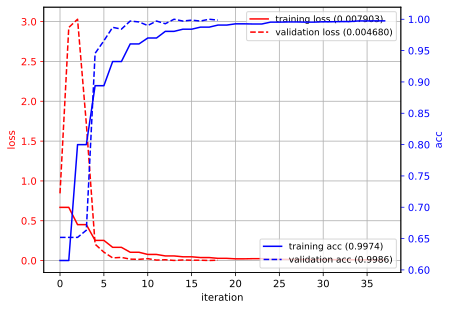

In [281]:
model_s55 = FaceCNN19(width=64, depths=(4,4,4), k=3, dropout=0.30)
name = "S-55"  
history_G005 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
train_dataset = AugmentedTensorDataset(trainI, trainYb, transform=EXPERIMENTS[name])
valid_dataset = TensorDataset(validI, validYb)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1024, shuffle=False)
# criterion = nn.CrossEntropyLoss()
earlystop_aug_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_aug_cnn = [earlystop_aug_cnn]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

print(device)

model_s55 = model_s55.to(device)
# if torch.cuda.device_count() >= 2:
#     print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
#     model_aug_cnn = nn.DataParallel(model_aug_cnn, device_ids=[0, 1])  # 关键一行

criterion = nn.CrossEntropyLoss().to(device)
# primary = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = optim.SGD(model_aug_cnn.parameters(), lr=3e-4, momentum=0.9, nesterov=True)
optimizer = torch.optim.AdamW(model_s55.parameters(), lr=3e-3, weight_decay=1e-2)

for epoch in range(epochs):
    model_s55.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # model_aug_cnn = model_aug_cnn.to(device)
        optimizer.zero_grad()
        # print(f"optimizer device: {optimizer.param_groups[0]['params']}")
        # print(F"batch_x device: {batch_x.device}")
        # print(F"batch_y device: {batch_y.device}")
        # print(f"model device: {model_aug_cnn.parameters()}")
        outputs = model_s55(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_G005['loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)

    # Validation phase
    model_s55.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_s55(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_G005[
        'loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)
    history_G005['val_loss'].append(val_loss)
    history_G005['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Check for early stopping
    earlystop_aug_cnn(val_accuracy)
    if earlystop_aug_cnn.early_stop:
        break

plot_history(HistoryWrapper(history_G005))
model_s55.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_aug_cnn = model_s55(testI)
    predY_aug_cnn = pred_outputs_aug_cnn.argmax(dim=1).detach().cpu().numpy()
acc_aug_cnn = metrics.accuracy_score(testY, predY_aug_cnn)
print("test accuracy:", acc_aug_cnn)

cuda
Epoch [1/50], Train Loss: 0.7037, Train Accuracy: 0.6261, Val Loss: 0.6602, Val Accuracy: 0.6519
Epoch [2/50], Train Loss: 0.6271, Train Accuracy: 0.6586, Val Loss: 0.6900, Val Accuracy: 0.6519
Epoch [3/50], Train Loss: 0.5016, Train Accuracy: 0.7450, Val Loss: 1.6560, Val Accuracy: 0.6519
Epoch [4/50], Train Loss: 0.3061, Train Accuracy: 0.8772, Val Loss: 1.9757, Val Accuracy: 0.6519
Epoch [5/50], Train Loss: 0.2565, Train Accuracy: 0.8947, Val Loss: 1.0554, Val Accuracy: 0.7163
Epoch [6/50], Train Loss: 0.2027, Train Accuracy: 0.9184, Val Loss: 2.2862, Val Accuracy: 0.6519
Epoch [7/50], Train Loss: 0.1864, Train Accuracy: 0.9296, Val Loss: 2.0158, Val Accuracy: 0.6519
Epoch [8/50], Train Loss: 0.1589, Train Accuracy: 0.9375, Val Loss: 2.0677, Val Accuracy: 0.6519
Epoch [9/50], Train Loss: 0.1280, Train Accuracy: 0.9485, Val Loss: 2.3071, Val Accuracy: 0.6519
Epoch [10/50], Train Loss: 0.1136, Train Accuracy: 0.9576, Val Loss: 0.2689, Val Accuracy: 0.9198
Epoch [11/50], Train Los

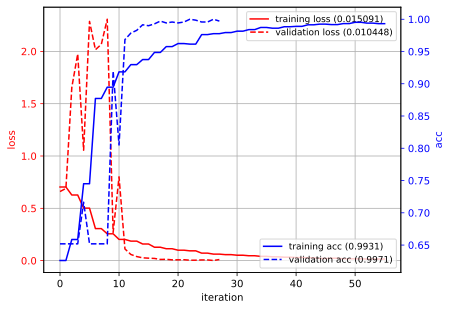

In [287]:
model_g01c10 = FaceCNN19(width=64, depths=(4,4,4), k=3, dropout=0.30)
name = "G01+C10"  
history_G005 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
train_dataset = AugmentedTensorDataset(trainI, trainYb, transform=EXPERIMENTS[name])
valid_dataset = TensorDataset(validI, validYb)
train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=2048, shuffle=False)
# criterion = nn.CrossEntropyLoss()
earlystop_aug_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_aug_cnn = [earlystop_aug_cnn]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

print(device)

model_g01c10 = model_g01c10.to(device)
# if torch.cuda.device_count() >= 2:
#     print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
#     model_aug_cnn = nn.DataParallel(model_aug_cnn, device_ids=[0, 1])  # 关键一行

criterion = nn.CrossEntropyLoss().to(device)
# primary = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = optim.SGD(model_aug_cnn.parameters(), lr=3e-4, momentum=0.9, nesterov=True)
optimizer = torch.optim.AdamW(model_g01c10.parameters(), lr=3e-3, weight_decay=1e-2)

for epoch in range(epochs):
    model_g01c10.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # model_aug_cnn = model_aug_cnn.to(device)
        optimizer.zero_grad()
        # print(f"optimizer device: {optimizer.param_groups[0]['params']}")
        # print(F"batch_x device: {batch_x.device}")
        # print(F"batch_y device: {batch_y.device}")
        # print(f"model device: {model_aug_cnn.parameters()}")
        outputs = model_g01c10(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_G005['loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)

    # Validation phase
    model_g01c10.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_g01c10(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_G005[
        'loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)
    history_G005['val_loss'].append(val_loss)
    history_G005['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Check for early stopping
    earlystop_aug_cnn(val_accuracy)
    if earlystop_aug_cnn.early_stop:
        break

plot_history(HistoryWrapper(history_G005))
model_g01c10.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_aug_cnn = model_g01c10(testI)
    predY_aug_cnn = pred_outputs_aug_cnn.argmax(dim=1).detach().cpu().numpy()
acc_aug_cnn = metrics.accuracy_score(testY, predY_aug_cnn)
print("test accuracy:", acc_aug_cnn)

cuda
Epoch [1/50], Train Loss: 0.6431, Train Accuracy: 0.6110, Val Loss: 1.3569, Val Accuracy: 0.6519
Epoch [2/50], Train Loss: 0.4501, Train Accuracy: 0.7880, Val Loss: 3.8064, Val Accuracy: 0.6519
Epoch [3/50], Train Loss: 0.2989, Train Accuracy: 0.8780, Val Loss: 2.1318, Val Accuracy: 0.6519
Epoch [4/50], Train Loss: 0.2111, Train Accuracy: 0.9160, Val Loss: 1.8816, Val Accuracy: 0.6519
Epoch [5/50], Train Loss: 0.1575, Train Accuracy: 0.9356, Val Loss: 1.8879, Val Accuracy: 0.6519
Epoch [6/50], Train Loss: 0.1175, Train Accuracy: 0.9546, Val Loss: 1.6233, Val Accuracy: 0.6691
Epoch [7/50], Train Loss: 0.0808, Train Accuracy: 0.9688, Val Loss: 1.5164, Val Accuracy: 0.7163
Epoch [8/50], Train Loss: 0.0690, Train Accuracy: 0.9766, Val Loss: 0.9085, Val Accuracy: 0.8066
Epoch [9/50], Train Loss: 0.0593, Train Accuracy: 0.9798, Val Loss: 0.9338, Val Accuracy: 0.7980
Epoch [10/50], Train Loss: 0.0460, Train Accuracy: 0.9844, Val Loss: 0.2570, Val Accuracy: 0.9298
Epoch [11/50], Train Los

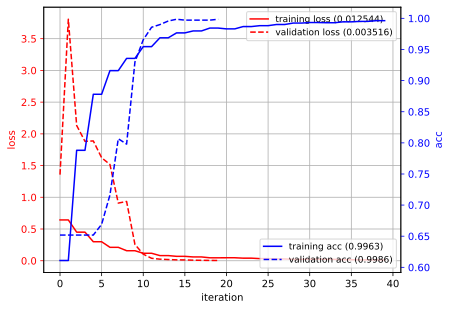

In [293]:
model_g02s52 = FaceCNN19(width=64, depths=(4,4,4), k=3, dropout=0.30)
name = "G02+S52"  
history_G005 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
train_dataset = AugmentedTensorDataset(trainI, trainYb, transform=EXPERIMENTS[name])
valid_dataset = TensorDataset(validI, validYb)
train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=2048, shuffle=False)
# criterion = nn.CrossEntropyLoss()
earlystop_aug_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_aug_cnn = [earlystop_aug_cnn]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

print(device)

model_g02s52 = model_g02s52.to(device)
# if torch.cuda.device_count() >= 2:
#     print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
#     model_aug_cnn = nn.DataParallel(model_aug_cnn, device_ids=[0, 1])  # 关键一行

criterion = nn.CrossEntropyLoss().to(device)
# primary = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = optim.SGD(model_aug_cnn.parameters(), lr=3e-4, momentum=0.9, nesterov=True)
optimizer = torch.optim.AdamW(model_g02s52.parameters(), lr=3e-3, weight_decay=1e-2)

for epoch in range(epochs):
    model_g02s52.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # model_aug_cnn = model_aug_cnn.to(device)
        optimizer.zero_grad()
        # print(f"optimizer device: {optimizer.param_groups[0]['params']}")
        # print(F"batch_x device: {batch_x.device}")
        # print(F"batch_y device: {batch_y.device}")
        # print(f"model device: {model_aug_cnn.parameters()}")
        outputs = model_g02s52(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_G005['loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)

    # Validation phase
    model_g02s52.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_g02s52(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_G005[
        'loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)
    history_G005['val_loss'].append(val_loss)
    history_G005['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Check for early stopping
    earlystop_aug_cnn(val_accuracy)
    if earlystop_aug_cnn.early_stop:
        break

plot_history(HistoryWrapper(history_G005))
model_g02s52.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_aug_cnn = model_g02s52(testI)
    predY_aug_cnn = pred_outputs_aug_cnn.argmax(dim=1).detach().cpu().numpy()
acc_aug_cnn = metrics.accuracy_score(testY, predY_aug_cnn)
print("test accuracy:", acc_aug_cnn)

cuda
Epoch [1/50], Train Loss: 0.7004, Train Accuracy: 0.5975, Val Loss: 0.6529, Val Accuracy: 0.6519
Epoch [2/50], Train Loss: 0.6365, Train Accuracy: 0.6566, Val Loss: 0.6627, Val Accuracy: 0.6519
Epoch [3/50], Train Loss: 0.5425, Train Accuracy: 0.7248, Val Loss: 1.5643, Val Accuracy: 0.6519
Epoch [4/50], Train Loss: 0.3490, Train Accuracy: 0.8507, Val Loss: 2.4664, Val Accuracy: 0.6519
Epoch [5/50], Train Loss: 0.2606, Train Accuracy: 0.8895, Val Loss: 1.4885, Val Accuracy: 0.6533
Epoch [6/50], Train Loss: 0.2254, Train Accuracy: 0.9088, Val Loss: 1.7124, Val Accuracy: 0.6576
Epoch [7/50], Train Loss: 0.2042, Train Accuracy: 0.9146, Val Loss: 2.9956, Val Accuracy: 0.6519
Epoch [8/50], Train Loss: 0.1900, Train Accuracy: 0.9263, Val Loss: 3.0913, Val Accuracy: 0.6519
Epoch [9/50], Train Loss: 0.1639, Train Accuracy: 0.9371, Val Loss: 2.7012, Val Accuracy: 0.6533
Epoch [10/50], Train Loss: 0.1436, Train Accuracy: 0.9444, Val Loss: 1.5573, Val Accuracy: 0.7020
Epoch [11/50], Train Los

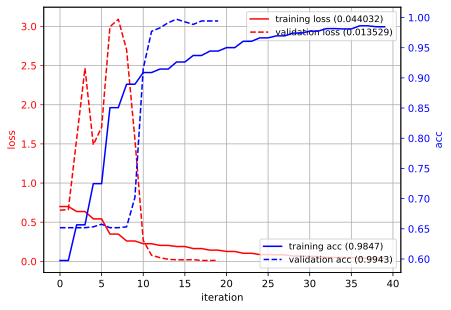

In [297]:
model_c10s52 = FaceCNN19(width=64, depths=(4,4,4), k=3, dropout=0.30)
name = "C10+S52"  
history_G005 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
train_dataset = AugmentedTensorDataset(trainI, trainYb, transform=EXPERIMENTS[name])
valid_dataset = TensorDataset(validI, validYb)
train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=2048, shuffle=False)
# criterion = nn.CrossEntropyLoss()
earlystop_aug_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_aug_cnn = [earlystop_aug_cnn]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

print(device)

model_c10s52 = model_c10s52.to(device)
# if torch.cuda.device_count() >= 2:
#     print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
#     model_aug_cnn = nn.DataParallel(model_aug_cnn, device_ids=[0, 1])  # 关键一行

criterion = nn.CrossEntropyLoss().to(device)
# primary = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = optim.SGD(model_aug_cnn.parameters(), lr=3e-4, momentum=0.9, nesterov=True)
optimizer = torch.optim.AdamW(model_c10s52.parameters(), lr=3e-3, weight_decay=1e-2)

for epoch in range(epochs):
    model_c10s52.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # model_aug_cnn = model_aug_cnn.to(device)
        optimizer.zero_grad()
        # print(f"optimizer device: {optimizer.param_groups[0]['params']}")
        # print(F"batch_x device: {batch_x.device}")
        # print(F"batch_y device: {batch_y.device}")
        # print(f"model device: {model_aug_cnn.parameters()}")
        outputs = model_c10s52(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_G005['loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)

    # Validation phase
    model_c10s52.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_c10s52(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_G005[
        'loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)
    history_G005['val_loss'].append(val_loss)
    history_G005['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Check for early stopping
    earlystop_aug_cnn(val_accuracy)
    if earlystop_aug_cnn.early_stop:
        break

plot_history(HistoryWrapper(history_G005))
model_c10s52.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_aug_cnn = model_c10s52(testI)
    predY_aug_cnn = pred_outputs_aug_cnn.argmax(dim=1).detach().cpu().numpy()
acc_aug_cnn = metrics.accuracy_score(testY, predY_aug_cnn)
print("test accuracy:", acc_aug_cnn)

cuda
Epoch [1/50], Train Loss: 0.6890, Train Accuracy: 0.6279, Val Loss: 0.6688, Val Accuracy: 0.6519
Epoch [2/50], Train Loss: 0.5872, Train Accuracy: 0.6865, Val Loss: 2.6667, Val Accuracy: 0.6519
Epoch [3/50], Train Loss: 0.4061, Train Accuracy: 0.8294, Val Loss: 2.7687, Val Accuracy: 0.6662
Epoch [4/50], Train Loss: 0.2818, Train Accuracy: 0.8828, Val Loss: 0.7042, Val Accuracy: 0.8510
Epoch [5/50], Train Loss: 0.2176, Train Accuracy: 0.9081, Val Loss: 1.1652, Val Accuracy: 0.7521
Epoch [6/50], Train Loss: 0.1655, Train Accuracy: 0.9358, Val Loss: 1.5610, Val Accuracy: 0.6590
Epoch [7/50], Train Loss: 0.1346, Train Accuracy: 0.9475, Val Loss: 0.8221, Val Accuracy: 0.7221
Epoch [8/50], Train Loss: 0.1110, Train Accuracy: 0.9581, Val Loss: 0.7147, Val Accuracy: 0.8181
Epoch [9/50], Train Loss: 0.0851, Train Accuracy: 0.9680, Val Loss: 0.4358, Val Accuracy: 0.8840
Epoch [10/50], Train Loss: 0.0802, Train Accuracy: 0.9719, Val Loss: 0.2301, Val Accuracy: 0.9269
Epoch [11/50], Train Los

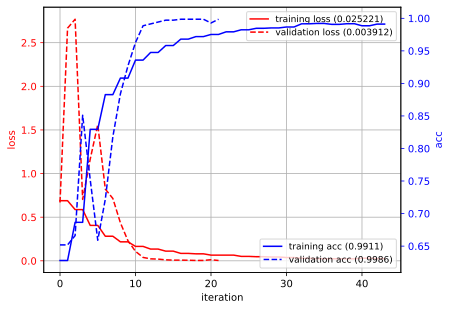

In [306]:
model_weak = FaceCNN19(width=64, depths=(4,4,4), k=3, dropout=0.30)
name = "Weak"  
history_G005 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
train_dataset = AugmentedTensorDataset(trainI, trainYb, transform=EXPERIMENTS[name])
valid_dataset = TensorDataset(validI, validYb)
train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=2048, shuffle=False)
# criterion = nn.CrossEntropyLoss()
earlystop_aug_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_aug_cnn = [earlystop_aug_cnn]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

print(device)

model_weak = model_weak.to(device)
# if torch.cuda.device_count() >= 2:
#     print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
#     model_aug_cnn = nn.DataParallel(model_aug_cnn, device_ids=[0, 1])  # 关键一行

criterion = nn.CrossEntropyLoss().to(device)
# primary = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = optim.SGD(model_aug_cnn.parameters(), lr=3e-4, momentum=0.9, nesterov=True)
optimizer = torch.optim.AdamW(model_weak.parameters(), lr=3e-3, weight_decay=1e-2)

for epoch in range(epochs):
    model_weak.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # model_aug_cnn = model_aug_cnn.to(device)
        optimizer.zero_grad()
        # print(f"optimizer device: {optimizer.param_groups[0]['params']}")
        # print(F"batch_x device: {batch_x.device}")
        # print(F"batch_y device: {batch_y.device}")
        # print(f"model device: {model_aug_cnn.parameters()}")
        outputs = model_weak(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_G005['loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)

    # Validation phase
    model_weak.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_weak(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_G005[
        'loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)
    history_G005['val_loss'].append(val_loss)
    history_G005['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Check for early stopping
    earlystop_aug_cnn(val_accuracy)
    if earlystop_aug_cnn.early_stop:
        break

plot_history(HistoryWrapper(history_G005))
model_weak.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_aug_cnn = model_weak(testI)
    predY_aug_cnn = pred_outputs_aug_cnn.argmax(dim=1).detach().cpu().numpy()
acc_aug_cnn = metrics.accuracy_score(testY, predY_aug_cnn)
print("test accuracy:", acc_aug_cnn)

cuda
Epoch [1/50], Train Loss: 0.7017, Train Accuracy: 0.5864, Val Loss: 0.6561, Val Accuracy: 0.6519
Epoch [2/50], Train Loss: 0.6483, Train Accuracy: 0.6437, Val Loss: 1.1516, Val Accuracy: 0.6519
Epoch [3/50], Train Loss: 0.5781, Train Accuracy: 0.6746, Val Loss: 3.4353, Val Accuracy: 0.6519
Epoch [4/50], Train Loss: 0.4627, Train Accuracy: 0.7892, Val Loss: 1.7284, Val Accuracy: 0.6519
Epoch [5/50], Train Loss: 0.3192, Train Accuracy: 0.8620, Val Loss: 1.5203, Val Accuracy: 0.6519
Epoch [6/50], Train Loss: 0.2462, Train Accuracy: 0.9028, Val Loss: 0.8995, Val Accuracy: 0.7350
Epoch [7/50], Train Loss: 0.2230, Train Accuracy: 0.9103, Val Loss: 0.5063, Val Accuracy: 0.8395
Epoch [8/50], Train Loss: 0.1970, Train Accuracy: 0.9232, Val Loss: 0.6542, Val Accuracy: 0.7951
Epoch [9/50], Train Loss: 0.1668, Train Accuracy: 0.9362, Val Loss: 0.9155, Val Accuracy: 0.7206
Epoch [10/50], Train Loss: 0.1445, Train Accuracy: 0.9465, Val Loss: 0.6674, Val Accuracy: 0.8052
Epoch [11/50], Train Los

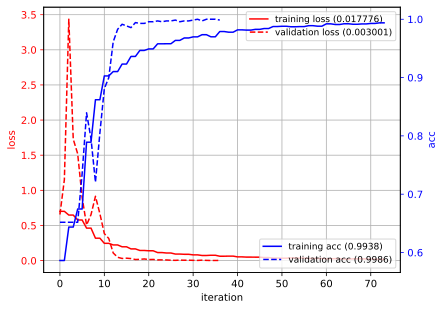

In [314]:
model_strong = FaceCNN19(width=64, depths=(4,4,4), k=3, dropout=0.30)
name = "Strong"  
history_G005 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
train_dataset = AugmentedTensorDataset(trainI, trainYb, transform=EXPERIMENTS[name])
valid_dataset = TensorDataset(validI, validYb)
train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=2048, shuffle=False)
# criterion = nn.CrossEntropyLoss()
earlystop_aug_cnn = EarlyStopping(monitor='val_accuracy', min_delta=0.0001, patience=5, verbose=1, mode='auto')
callbacks_list_aug_cnn = [earlystop_aug_cnn]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # 动态调优卷积算法

print(device)

model_strong = model_strong.to(device)
# if torch.cuda.device_count() >= 2:
#     print(f"Using {torch.cuda.device_count()} GPUs via DataParallel: [0,1]")
#     model_aug_cnn = nn.DataParallel(model_aug_cnn, device_ids=[0, 1])  # 关键一行

criterion = nn.CrossEntropyLoss().to(device)
# primary = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = optim.SGD(model_aug_cnn.parameters(), lr=3e-4, momentum=0.9, nesterov=True)
optimizer = torch.optim.AdamW(model_strong.parameters(), lr=3e-3, weight_decay=1e-2)

for epoch in range(epochs):
    model_strong.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # model_aug_cnn = model_aug_cnn.to(device)
        optimizer.zero_grad()
        # print(f"optimizer device: {optimizer.param_groups[0]['params']}")
        # print(F"batch_x device: {batch_x.device}")
        # print(F"batch_y device: {batch_y.device}")
        # print(f"model device: {model_aug_cnn.parameters()}")
        outputs = model_strong(batch_x)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    history_G005['loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)

    # Validation phase
    model_strong.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model_strong(batch_x)
            loss = criterion(outputs, torch.argmax(batch_y, dim=1))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == torch.argmax(batch_y, dim=1)).sum().item()

    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    history_G005[
        'loss'].append(train_loss)
    history_G005['accuracy'].append(train_accuracy)
    history_G005['val_loss'].append(val_loss)
    history_G005['val_accuracy'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Check for early stopping
    earlystop_aug_cnn(val_accuracy)
    if earlystop_aug_cnn.early_stop:
        break

plot_history(HistoryWrapper(history_G005))
model_strong.eval()
with torch.no_grad():
    testI = testI.to(device)
    pred_outputs_aug_cnn = model_strong(testI)
    predY_aug_cnn = pred_outputs_aug_cnn.argmax(dim=1).detach().cpu().numpy()
acc_aug_cnn = metrics.accuracy_score(testY, predY_aug_cnn)
print("test accuracy:", acc_aug_cnn)

_How does CNN with data augmentation compare with your work in Tutorial 8?_
- **INSERT YOUR ANSWER HERE**
- CNN with data augmentation improves the performance on testing dataset in general, with different augmentation strategy resulting in varying improvement levels.

# Test image
Now lets try your face detector on a real image.  Download the "nasa-small.png" image and put it in the same directory as your ipynb file.  The below code will load the image, crop out image patches and then extract features. (this may take a few minutes)

In [315]:
fname = "nasa-small.png"

(210, 480)


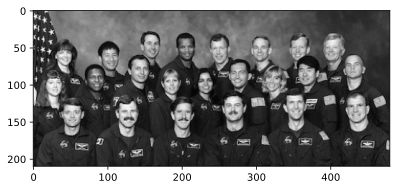

In [316]:
# load image
testimg = skimage.io.imread(fname, as_gray=True)
print(testimg.shape)
plt.imshow(testimg, cmap='gray')

In [317]:
# step size for the sliding window
step = 4

# extract window patches with step size of 4
patches = skimage.util.view_as_windows(testimg, (19,19), step=step)
psize = patches.shape
# collapse the first 2 dimensions
patches2 = patches.reshape((psize[0]*psize[1], psize[2], psize[3], 1))
print(patches2.shape)

# histogram equalize patches (improves contrast)
#newI = empty(patches2.shape)
#for i in range(patches2.shape[0]):
#    newI[i,:,:] = skimage.exposure.equalize_hist(patches2[i,:,:])
newI = patches2


(5568, 19, 19, 1)


Now predict using your classifier.  The extracted images are in `newI`.

In [326]:
### YOUR CODE HERE
newI = torch.FloatTensor(newI.transpose(0, 3, 1, 2)).to(device)
with torch.no_grad():
    outputs = model_aug_cnn(newI)
    prednewY = torch.argmax(outputs, dim=1).detach().cpu().numpy()

Now we we will view the results on the image.  Use the below code. `prednewY` is the vector of predictions.

/tmp/ipykernel_4108389/3555536941.py:5: DeprecationWarning: Please import `zoom` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  imgY2 = ndimage.interpolation.zoom(imgY, step, output=None, order=0)


(np.float64(-0.5), np.float64(479.5), np.float64(209.5), np.float64(-0.5))

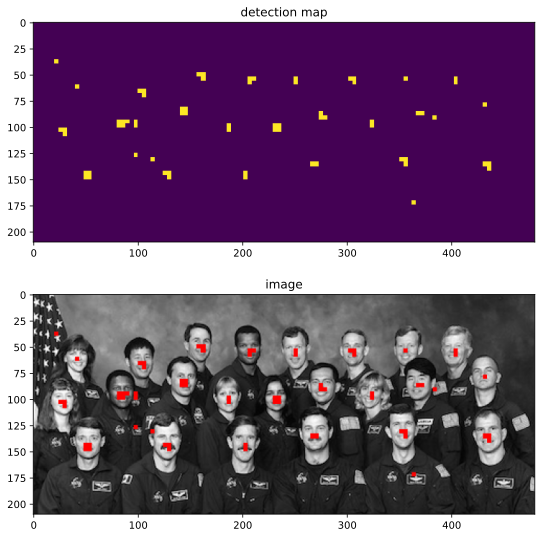

In [327]:
# reshape prediction to an image
imgY = prednewY.reshape(psize[0], psize[1])

# zoom back to image size
imgY2 = ndimage.interpolation.zoom(imgY, step, output=None, order=0)
# pad the top and left with half the window size
imgY2 = vstack((zeros((9, imgY2.shape[1])), imgY2))
imgY2 = hstack((zeros((imgY2.shape[0],9)), imgY2))
# pad right and bottom to same size as image
if (imgY2.shape[0] != testimg.shape[0]):
    imgY2 = vstack((imgY2, zeros((testimg.shape[0]-imgY2.shape[0], imgY2.shape[1]))))
if (imgY2.shape[1] != testimg.shape[1]):
    imgY2 = hstack((imgY2, zeros((imgY2.shape[0],testimg.shape[1]-imgY2.shape[1]))))

# show detections with image
#detimg = dstack(((0.5*imgY2+0.5)*testimg, 0.5*testimg, 0.5*testimg))
nimgY2 = 1-imgY2
tmp = nimgY2*testimg
detimg = dstack((imgY2+tmp, tmp, tmp))

# show it!
plt.figure(figsize=(9,9))
plt.subplot(2,1,1)
plt.imshow(imgY2, interpolation='nearest')
plt.title('detection map')
plt.subplot(2,1,2)
plt.imshow(detimg)
plt.title('image')
plt.axis('image')

_How did your face detector do compared to the last version?_
- **INSERT YOUR ANSWER HERE**
- Using the best experiment setting tested out above, the final detector significantly outperforms my last version in Tutorial 4. Tilted faces and those with less lighting can be accurately detected.

You can try it on your own images.  The faces should all be around 19x19 pixels though. We only used 1/8 of the training data. Try using more data to train it!

(162, 311)


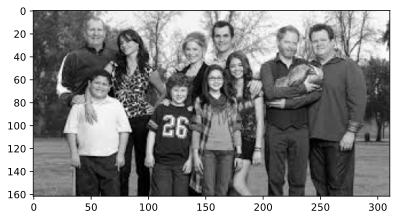

In [328]:
new_fname = "family_photo.png"
testing_img = skimage.io.imread(new_fname, as_gray=True)
print(testing_img.shape)
plt.imshow(testing_img, cmap='gray')

In [330]:
step = 4
patches = skimage.util.view_as_windows(testing_img, (19,19), step=step)
psize = patches.shape
# collapse the first 2 dimensions
patches2 = patches.reshape((psize[0]*psize[1], psize[2], psize[3], 1))
print(patches2.shape)
newI = patches2

(2664, 19, 19, 1)


In [331]:
### YOUR CODE HERE
newI = torch.FloatTensor(newI.transpose(0, 3, 1, 2)).to(device)
with torch.no_grad():
    outputs = model_aug_cnn(newI)
    prednewY = torch.argmax(outputs, dim=1).detach().cpu().numpy()

/tmp/ipykernel_4108389/200547353.py:5: DeprecationWarning: Please import `zoom` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  imgY2 = ndimage.interpolation.zoom(imgY, step, output=None, order=0)


(np.float64(-0.5), np.float64(310.5), np.float64(161.5), np.float64(-0.5))

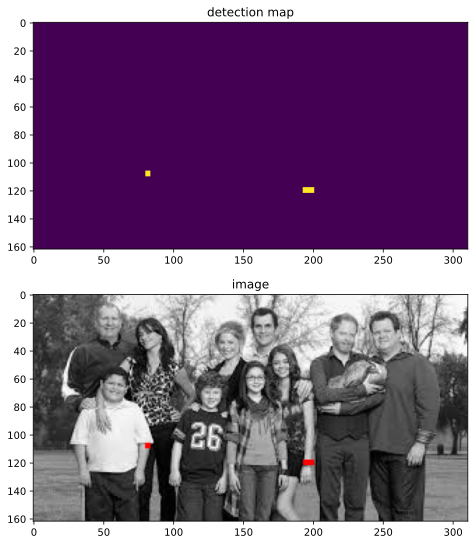

In [334]:
# reshape prediction to an image
imgY = prednewY.reshape(psize[0], psize[1])

# zoom back to image size
imgY2 = ndimage.interpolation.zoom(imgY, step, output=None, order=0)
# pad the top and left with half the window size
imgY2 = vstack((zeros((9, imgY2.shape[1])), imgY2))
imgY2 = hstack((zeros((imgY2.shape[0],9)), imgY2))
# pad right and bottom to same size as image
if (imgY2.shape[0] != testing_img.shape[0]):
    imgY2 = vstack((imgY2, zeros((testing_img.shape[0]-imgY2.shape[0], imgY2.shape[1]))))
if (imgY2.shape[1] != testing_img.shape[1]):
    imgY2 = hstack((imgY2, zeros((imgY2.shape[0],testing_img.shape[1]-imgY2.shape[1]))))

# show detections with image
#detimg = dstack(((0.5*imgY2+0.5)*testimg, 0.5*testimg, 0.5*testimg))
nimgY2 = 1-imgY2
tmp = nimgY2*testing_img
detimg = dstack((imgY2+tmp, tmp, tmp))

# show it!
plt.figure(figsize=(9,9))
plt.subplot(2,1,1)
plt.imshow(imgY2, interpolation='nearest')
plt.title('detection map')
plt.subplot(2,1,2)
plt.imshow(detimg)
plt.title('image')
plt.axis('image')

I think this photo is too different from the training data. Sad.